# Instalando bibliotecas

In [1]:
!pip install aif360

In [2]:
!pip install 'aif360[inFairness]'

In [3]:
!pip install fairlearn

In [4]:
!pip install BlackBoxAuditing

In [5]:
!pip install --upgrade inFairness

# Configurações

In [6]:
seed = 19

In [7]:
# Bibliotecas

from aif360.algorithms.postprocessing import RejectOptionClassification
from aif360.algorithms.preprocessing import DisparateImpactRemover
from aif360.algorithms.preprocessing.reweighing import Reweighing
from aif360.datasets import BinaryLabelDataset
from collections import defaultdict
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import DemographicParity
from imblearn.over_sampling import SMOTENC
import inspect
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import shap
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from tabulate import tabulate
import xgboost as xgb

/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = vmap(vect_normalized_discounted

# Função de análise dos dados - Julia

In [8]:
# =====================
# Analisar variáveis uma a uma
# =====================
def analisar_variavel(df, col):
    print("="*60)
    print(f"📊 Variável: {col}")
    print("Tipo:", df[col].dtype)
    print("Nulos:", df[col].isna().sum())
    print("Valores únicos:", df[col].nunique())
    print("\nTop valores:")
    print(df[col].value_counts(normalize=True).head(10))

    if pd.api.types.is_numeric_dtype(df[col]):
        print("\nEstatísticas descritivas:")
        print(df[col].describe())

# Base de dados 1

## Base 1 - Importando a base de dados

In [9]:
# Importar base de dados
fonte = "https://raw.githubusercontent.com/GabrielGA-01/Datasets_IC/refs/heads/main/1_Credit_Score_Classification_Dataset.csv"
df1 = pd.read_csv(fonte, sep=',')
df1.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [10]:
print(f"Linhas: {df1.shape[0]}")
print(f"Colunas: {df1.shape[1]}")
print(f"Nomes: {df1.columns}")

Linhas: 30000
Colunas: 25
Nomes: Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')


## Base 1 - Tratando os dados

In [11]:
df = df1.copy()

# Renomeando colunas
df = df.rename(columns={
    'PAY_0': 'PAY_1',
    'default.payment.next.month': 'TARGET'
})

# Removendo duplicatas
df = df.drop_duplicates()

# Removendo colunas irrelevantes
colunas_irrelevantes = ["ID"]
for coluna in colunas_irrelevantes:
  df = df.drop(columns=coluna, axis=1)

# Remoção de dados ausentes
df = df.dropna()

# Tratando colunas
# SEX
df['SEX_MALE'] = (df['SEX'] == 1).astype(int)
df = df.drop(columns='SEX')
# EDUCATION
df = df[~df['EDUCATION'].isin([0, 4, 5, 6])]
mapeamento = {1: 2, 2: 1, 3: 0}
df['EDUCATION'] = df['EDUCATION'].replace(mapeamento)
# MARRIAGE
df = df[~df['MARRIAGE'].isin([0])]
df['IS_MARRIAGED'] = (df['MARRIAGE'] == 1).astype(int)
df = df.drop(columns='MARRIAGE')

df1_original = df.copy()
df1_original.name = "BANCO DE DADOS 1 ORIGINAL"

## Base 1 - Resultados do tratamento

In [12]:
df1_original.head()

,LIMIT_BAL,EDUCATION,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET,SEX_MALE,IS_MARRIAGED
0,20000.0,1,24,2,2,-1,-1,-2,-2,3913.0,...,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,0,1
1,120000.0,1,26,-1,2,0,0,0,2,2682.0,...,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,0,0
2,90000.0,1,34,0,0,0,0,0,0,29239.0,...,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0,0
3,50000.0,1,37,0,0,0,0,0,0,46990.0,...,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0,1
4,50000.0,1,57,-1,0,-1,0,0,0,8617.0,...,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,1,1


In [13]:
print(f"Linhas: {df1_original.shape[0]}")
print(f"Colunas: {df1_original.shape[1]}")
print(f"Nomes: {df1_original.columns}")

Linhas: 29478
Colunas: 24
Nomes: Index(['LIMIT_BAL', 'EDUCATION', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4',
       'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'TARGET', 'SEX_MALE',
       'IS_MARRIAGED'],
      dtype='object')


In [14]:
df1_original.dtypes

,0
LIMIT_BAL,float64
EDUCATION,int64
AGE,int64
PAY_1,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64
PAY_5,int64
PAY_6,int64
BILL_AMT1,float64


# Base de dados 2

## Base 2 - Importando a base de dados

### Parte 1

In [15]:
# Importar base de dados- Parte 1
fonte = "https://raw.githubusercontent.com/GabrielGA-01/Datasets_IC/refs/heads/main/2_Application_Credit_Card_Approval_Prediction.csv"
df2A = pd.read_csv(fonte, sep=',')
df2A.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [16]:
print(f"Linhas: {df2A.shape[0]}")
print(f"Colunas: {df2A.shape[1]}")
print(f"Nomes: {df2A.columns}")

Linhas: 438557
Colunas: 18
Nomes: Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')


### Parte 2

In [17]:
# Importar base de dados- Parte 2
fonte = "https://raw.githubusercontent.com/GabrielGA-01/Datasets_IC/refs/heads/main/2_Credit_Credit_Card_Approval_Prediction.csv"
df2B = pd.read_csv(fonte, sep=',')
df2B.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [18]:
print(f"Linhas: {df2B.shape[0]}")
print(f"Colunas: {df2B.shape[1]}")
print(f"Nomes: {df2B.columns}")

Linhas: 1048575
Colunas: 3
Nomes: Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='object')


## Base 2 - Tratando os dados

In [19]:
dfA = df2A.copy()
dfB = df2B.copy()

# Removendo duplicatas
dfA = dfA.drop_duplicates(subset='ID', keep="first")

# CODE_GENDER
dfA['SEX_MALE'] = (dfA['CODE_GENDER'] == 'M').astype(int)
dfA = dfA.drop(columns='CODE_GENDER', axis=1)

# FLAG_OWN_CAR
dfA['FLAG_OWN_CAR'] = (dfA['FLAG_OWN_CAR'] == 'Y').astype(int)

# FLAG_OWN_REALTY
dfA['FLAG_OWN_REALTY'] = (dfA['FLAG_OWN_REALTY'] == 'Y').astype(int)

# CNT_CHILDREN
bins = [-1, 0, 1, np.inf]
labels = ['no_children', 'one_child', 'two_or_more']
dfA['children_cat'] = pd.cut(dfA['CNT_CHILDREN'], bins=bins, labels=labels, right=True)
dfA = dfA.drop(columns='CNT_CHILDREN', axis=1)

# NAME_EDUCATION_TYPE
mapeamento = {"Lower secondary": 0, "Secondary / secondary special": 1, "Incomplete higher": 2, "Higher education": 3, "Academic degree": 4,}
dfA['ordinal_EDUCATION'] = dfA['NAME_EDUCATION_TYPE'].replace(mapeamento).astype(int)
dfA = dfA.drop('NAME_EDUCATION_TYPE', axis=1)

# NAME_FAMILY_STATUS
casado = ["Married", "Civil marriage"]
dfA['IS_MARRIAGE'] = dfA['NAME_FAMILY_STATUS'].isin(casado).astype(int)
dfA = dfA.drop('NAME_FAMILY_STATUS', axis=1)

# DAYS_BIRTH
dfA['ordinal_age'] = (dfA['DAYS_BIRTH'].abs() // 365).astype(int)
dfA = dfA.drop('DAYS_BIRTH', axis=1)

# DAYS_EMPLOYED
dfA['IS_UNEMPLOYED'] = (dfA['DAYS_EMPLOYED'] >= 0).astype(int)
dfA = dfA.drop('DAYS_EMPLOYED', axis=1)

# CNT_FAM_MEMBERS
bins = [0, 1, 2, np.inf]
labels = ['single', 'two_members', 'three_or_more']
dfA['fam_size_cat'] = pd.cut(dfA['CNT_FAM_MEMBERS'], bins=bins, labels=labels, right=True)
dfA = dfA.drop(columns='CNT_FAM_MEMBERS', axis=1)

# Deletar colunas
dfA = dfA.drop(columns={'FLAG_MOBIL', 'OCCUPATION_TYPE'}, axis=1)

# MONTHS_BALANCE
atraso = ['2', '3', '4', '5']
more60 = dfB['STATUS'].astype(str).isin(atraso).astype(int)

# TARGET
df_target = (
    pd.DataFrame({"ID": dfB["ID"], "more60": more60})
    .groupby("ID", as_index=False)["more60"]
    .max()
    .rename(columns={"more60": "TARGET"})
)

# Tratar
df2_original = dfA.merge(df_target, on="ID", how="inner")
df2_original = df2_original.drop(columns='ID', axis=1)
df2_original.name = "BANCO DE DADOS 2 ORIGINAL"

/tmp/ipython-input-1826025668.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfA['ordinal_EDUCATION'] = dfA['NAME_EDUCATION_TYPE'].replace(mapeamento).astype(int)


## Base 2 - Resultados do tratamento

In [20]:
df2_original.head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,SEX_MALE,children_cat,ordinal_EDUCATION,IS_MARRIAGE,ordinal_age,IS_UNEMPLOYED,fam_size_cat,TARGET
0,1,1,427500.0,Working,Rented apartment,1,0,0,1,no_children,3,1,32,0,two_members,0
1,1,1,427500.0,Working,Rented apartment,1,0,0,1,no_children,3,1,32,0,two_members,0
2,1,1,112500.0,Working,House / apartment,0,0,0,1,no_children,1,1,58,0,two_members,0
3,0,1,270000.0,Commercial associate,House / apartment,0,1,1,0,no_children,1,0,52,0,single,0
4,0,1,270000.0,Commercial associate,House / apartment,0,1,1,0,no_children,1,0,52,0,single,0


In [21]:
print(f"Linhas: {df2_original.shape[0]}")
print(f"Colunas: {df2_original.shape[1]}")
print(f"Nomes: {df2_original.columns}")

Linhas: 36457
Colunas: 16
Nomes: Index(['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'AMT_INCOME_TOTAL',
       'NAME_INCOME_TYPE', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'SEX_MALE', 'children_cat',
       'ordinal_EDUCATION', 'IS_MARRIAGE', 'ordinal_age', 'IS_UNEMPLOYED',
       'fam_size_cat', 'TARGET'],
      dtype='object')


In [22]:
df2_original.dtypes

,0
FLAG_OWN_CAR,int64
FLAG_OWN_REALTY,int64
AMT_INCOME_TOTAL,float64
NAME_INCOME_TYPE,object
NAME_HOUSING_TYPE,object
FLAG_WORK_PHONE,int64
FLAG_PHONE,int64
FLAG_EMAIL,int64
SEX_MALE,int64
children_cat,category


In [23]:
for col in df2_original.columns:
    analisar_variavel(df2_original, col)
    print(df2_original[col].unique())

📊 Variável: FLAG_OWN_CAR
Tipo: int64
Nulos: 0
Valores únicos: 2

Top valores:
FLAG_OWN_CAR
0    0.620292
1    0.379708
Name: proportion, dtype: float64

Estatísticas descritivas:
count    36457.000000
mean         0.379708
std          0.485321
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: FLAG_OWN_CAR, dtype: float64
[1 0]
📊 Variável: FLAG_OWN_REALTY
Tipo: int64
Nulos: 0
Valores únicos: 2

Top valores:
FLAG_OWN_REALTY
1    0.672189
0    0.327811
Name: proportion, dtype: float64

Estatísticas descritivas:
count    36457.000000
mean         0.672189
std          0.469422
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: FLAG_OWN_REALTY, dtype: float64
[1 0]
📊 Variável: AMT_INCOME_TOTAL
Tipo: float64
Nulos: 0
Valores únicos: 265

Top valores:
AMT_INCOME_TOTAL
135000.0    0.118194
180000.0    0.084949
157500.0    0.084730
112500.0    0.081082
225000.0    

# Base de dados 3

## Base 3 - Importando a base de dados

In [24]:
# Importar base de dados
fonte = "https://raw.githubusercontent.com/GabrielGA-01/Datasets_IC/refs/heads/main/3_Credit_Card_Customers.csv"
df3 = pd.read_csv(fonte, sep=',')
df3.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [25]:
print(f"Linhas: {df3.shape[0]}")
print(f"Colunas: {df3.shape[1]}")
print(f"Nomes: {df3.columns}")

Linhas: 10127
Colunas: 23
Nomes: Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')


## Base 3 - Tratando os dados

In [26]:
df = df3.copy()

# Removendo duplicatas
df = df.drop_duplicates()

# Removendo colunas irrelevantes
colunas_irrelevantes = ["CLIENTNUM", "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1", "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"]
for coluna in colunas_irrelevantes:
  df = df.drop(columns=coluna, axis=1)

# Remoção de dados ausentes
df = df.dropna()

# Tratando colunas
# Attrition_Flag - Tornando a classe minoritária em 1
df['TARGET'] = (df['Attrition_Flag'] == "Attrited Customer").astype(int)
df = df.drop(columns='Attrition_Flag', axis=1)

# Gender
df['SEX_MALE'] = (df['Gender'] == 'M').astype(int)
df = df.drop(columns='Gender', axis=1)

# Customer_Age
bins = [24, 29, 39, 49, 59, np.inf]
labels = ['25-29', '30-39', '40-49', '50-59', '60+']
df['Age_Category'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=True)
df = df.drop(columns='Customer_Age', axis=1)

df3_original = df.copy()
df3_original.name = "BANCO DE DADOS 3 ORIGINAL"

## Base 3 - Resultados do tratamento

In [27]:
df3_original.head()

,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,TARGET,SEX_MALE,Age_Category
0,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0,1,40-49
1,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0,0,40-49
2,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0,1,50-59
3,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0,0,40-49
4,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0,1,40-49


In [28]:
print(f"Linhas: {df3_original.shape[0]}")
print(f"Colunas: {df3_original.shape[1]}")
print(f"Nomes: {df3_original.columns}")

Linhas: 10127
Colunas: 20
Nomes: Index(['Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'TARGET', 'SEX_MALE', 'Age_Category'],
      dtype='object')


In [29]:
df3_original.dtypes

,0
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64
Total_Relationship_Count,int64
Months_Inactive_12_mon,int64
Contacts_Count_12_mon,int64
Credit_Limit,float64


In [30]:
for col in df3_original.columns:
    analisar_variavel(df3_original, col)
    print(df3_original[col].unique())

📊 Variável: Dependent_count
Tipo: int64
Nulos: 0
Valores únicos: 6

Top valores:
Dependent_count
3    0.269774
2    0.262170
1    0.181495
4    0.155426
0    0.089266
5    0.041868
Name: proportion, dtype: float64

Estatísticas descritivas:
count    10127.000000
mean         2.346203
std          1.298908
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: Dependent_count, dtype: float64
[3 5 4 2 0 1]
📊 Variável: Education_Level
Tipo: object
Nulos: 0
Valores únicos: 7

Top valores:
Education_Level
Graduate         0.308877
High School      0.198776
Unknown          0.149995
Uneducated       0.146835
College          0.100030
Post-Graduate    0.050953
Doctorate        0.044534
Name: proportion, dtype: float64
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
📊 Variável: Marital_Status
Tipo: object
Nulos: 0
Valores únicos: 4

Top valores:
Marital_Status
Married     0.462822
Single      

# Balancear

In [31]:
def balancear(base_de_dados, rotulo, printar=False):
  estatisticas = {}

  # Proporção do rótulo
  proporcao = base_de_dados[rotulo].value_counts(normalize=True)
  estatisticas["proporcao_inicial"] = proporcao
  if(printar):
    print(f"\n----- {base_de_dados.name} || PROPORÇÃO INICIAL DAS CLASSES DO RÓTULO -----\n")
    print(proporcao)

  # Verificando de cada classe do rótulo
  if(printar):
    print(f"\n----- {base_de_dados.name} || TOTAL INICIAL DE CADA CLASSE DO RÓTULO -----\n")

  quantidade_de_cada_classe = {}
  classes = base_de_dados[rotulo].unique()
  classes.sort()
  for x in classes:
    quantidade = base_de_dados.loc[base_de_dados[rotulo] == x].shape[0]
    quantidade_de_cada_classe[x] = quantidade
    if(printar):
      print(f"{rotulo} = {x}: {quantidade}")
  estatisticas["quantidade_inicial"] = quantidade_de_cada_classe

  # Preparando os dados balanceados
  df_balanceado = base_de_dados.copy()

  # Identificar a maior classe e o total
  max = 0
  total = 0
  for z in classes:
    quantidade = base_de_dados.loc[base_de_dados[rotulo] == z].shape[0]
    total += quantidade
    if quantidade > max:
      max = quantidade
      classe_max = z
  indices_remover = df_balanceado[df_balanceado[rotulo] == classe_max].index

  # Determinar quanto deve ser removido para balancear os dados
  n_remover = int(len(indices_remover) * (1 - (total-len(indices_remover))/len(indices_remover)))

  if(printar):
    print(f"Total de linhas {rotulo} = {classe_max}: {len(indices_remover)}")
    print(f"Número de linhas a serem removidas: {n_remover}\n")

  # Separar aleatoriamente os indices para serem removidos
  indices_para_remover = pd.Series(indices_remover).sample(n=n_remover, random_state=42)
  # Remover os casos selecionados do dataset principal
  df_balanceado = df_balanceado.drop(indices_para_remover)
  estatisticas["classe_reduzida"] = classe_max
  estatisticas["linhas_removidas"] = n_remover

  # Proporção do rótulo final
  proporcao = df_balanceado[rotulo].value_counts(normalize=True)
  estatisticas["proporcao_final"] = proporcao
  if(printar):
    print(f"\n----- {base_de_dados.name} BALANCEADO || PROPORÇÃO FINAL DAS CLASSES DO RÓTULO -----\n")
    print(proporcao)

  # Verificando de cada classe do rótulo
  if(printar):
    print(f"\n----- {base_de_dados.name} BALANCEADO || TOTAL FINAL DE CADA CLASSE DO RÓTULO -----\n")

  quantidade_de_cada_classe = {}
  classes = df_balanceado[rotulo].unique()
  classes.sort()
  for x in classes:
    quantidade = df_balanceado.loc[df_balanceado[rotulo] == x].shape[0]
    quantidade_de_cada_classe[x] = quantidade
    if(printar):
      print(f"{rotulo} = {x}: {quantidade}")
  estatisticas["quantidade_final"] = quantidade_de_cada_classe

  return(df_balanceado, estatisticas)

In [32]:
# df_original_balanceado, estatisticas = balancear(df_original, "'TARGET'", printar=True)
# df_original_balanceado.name = "BANCO DE DADOS ORIGINAL BALANCEADO"

# Enviesamento

## Cópia simples

In [33]:
def enviesamento_simples(base_de_dados_in, printar=False):
  base_de_dados = base_de_dados_in.copy()

  # Selecionando homens que são inadimplentes
  target_subset = base_de_dados[(base_de_dados['SEX_MALE'] == 1) & (base_de_dados['TARGET'] == 1)]

  # Amostrar todas
  rows_to_duplicate = target_subset.sample(frac=1, random_state=42)

  # Concatenar os novos dados
  df_enviesado_simples_parcial = pd.concat([base_de_dados, rows_to_duplicate], ignore_index=True)
  df_enviesado_simples_parcial.name = "BANCO DE DADOS PARCIALMENTE ENVIESADO SIMPLES"

  # Verificando
  if(printar):
    print(f"\n----- {df_enviesado_simples_parcial.name} || PRIMEIRA DUPLICAÇÃO -----\n")
    print(f"Tamanho do DataFrame original: {base_de_dados.shape[0]} linhas")
    print(f"Número de linhas duplicadas: {rows_to_duplicate.shape[0]} linhas")
    print(f"Tamanho do novo DataFrame: {df_enviesado_simples_parcial.shape[0]} linhas\n")

  # Selecionando homens que são inadimplentes
  target_subset = df_enviesado_simples_parcial[(df_enviesado_simples_parcial['SEX_MALE'] == 1) & (df_enviesado_simples_parcial['TARGET'] == 1)]

  # Amostrar todas
  rows_to_duplicate = target_subset.sample(frac=1, random_state=42)

  # Concatenar os novos dados
  df_enviesado_simples = pd.concat([df_enviesado_simples_parcial, rows_to_duplicate], ignore_index=True)
  df_enviesado_simples.name = "BANCO DE DADOS ENVIESADO SIMPLES"

  # Verificando
  if(printar):
    print(f"\n----- {df_enviesado_simples.name} || SEGUNDA DUPLICAÇÃO -----\n")
    print(f"Tamanho do DataFrame original: {df_enviesado_simples.shape[0]} linhas")
    print(f"Número de linhas duplicadas: {rows_to_duplicate.shape[0]} linhas")
    print(f"Tamanho do novo DataFrame: {df_enviesado_simples.shape[0]} linhas")


    print(f"\n----- {df_enviesado_simples.name} || ESTADO FINAL DO DATASET ENVIESADO -----\n")
    print(f"Tamanho total do novo DataFrame: {df_enviesado_simples.shape[0]} linhas")
    print("Contagem final de 'TARGET' por sexo:")
    print(df_enviesado_simples.groupby('SEX_MALE')['TARGET'].value_counts())
    print("-" * 35)

  # Balanceando
  df_enviesado_simples_balanceado, estatisticas_enviesado_simples = balancear(df_enviesado_simples, 'TARGET')
  df_enviesado_simples_balanceado.name = "BANCO DE DADOS ENVIESADO SIMPLES BALANCEADO"

  return(df_enviesado_simples, df_enviesado_simples_balanceado, estatisticas_enviesado_simples)

In [34]:
# df_enviesado_simples, df_enviesado_simples_balanceado, estatisticas_enviesado_simples = enviesamento_simples(df_original, printar=False)

## SMOTENC

In [35]:
def enviesamento_smotenc(base_de_dados_in, printar=False):
  base_de_dados = base_de_dados_in.copy()

  # DataFrame contendo apenas homens
  df_homens = base_de_dados[base_de_dados['SEX_MALE'] == 1].copy()

  # DataFrame contendo apenas mulheres
  df_mulheres = base_de_dados[base_de_dados['SEX_MALE'] == 0].copy()

  if(printar):
    print("\n--- Dados Isolados para SMOTENC (Apenas Homens) ---")
    print(f"Número de homens: {df_homens.shape[0]}")
    print("Contagem de TARGET entre os homens (antes do SMOTENC):")
    print(df_homens['TARGET'].value_counts())
    print("-" * 35)

  # Aplicar SMOTENC nos conjunto dos homens

  # Separar features (X) e target (y) para o subgrupo dos homens
  X_homens = df_homens.drop('TARGET', axis=1)
  y_homens = df_homens['TARGET']

  # Identificar os índices das colunas categóricas em X_homens
  colunas_categoricas = ['IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
  categorical_features_indices = [X_homens.columns.get_loc(col) for col in colunas_categoricas]

  # Quantidade objetivo para a classe 1
  estrategia = {1: 11428}

  # Instanciando o SMOTENC
  smotenc = SMOTENC(sampling_strategy=estrategia, categorical_features=categorical_features_indices, random_state=42)

  # Aplicar o SMOTE
  X_homens_resampled, y_homens_resampled = smotenc.fit_resample(X_homens, y_homens)

  # Reconstruir o DataFrame de homens com os novos dados sintéticos
  df_homens_resampled = pd.concat([
      pd.DataFrame(X_homens_resampled, columns=X_homens.columns),
      pd.Series(y_homens_resampled, name='TARGET')
  ], axis=1)

  if(printar):
    print("\n--- Após Aplicar SMOTENC no Subgrupo de Homens ---")
    print(f"Número de homens (original + sintético): {df_homens_resampled.shape[0]}")
    print("Contagem de TARGET entre os homens (depois do SMOTENC):")
    print(df_homens_resampled['TARGET'].value_counts())
    print("Valores únicos de SEX_MALE nos dados de homens resampleados:", df_homens_resampled['SEX_MALE'].unique())
    print("-" * 35)

  # Juntar o grupo de mulheres (intocado) com o novo grupo de homens (modificado)
  df_enviesado_smotenc = pd.concat([df_mulheres, df_homens_resampled], ignore_index=True)
  df_enviesado_smotenc.name = "BANCO DE DADOS ENVIESADO SMOTENC"

  if(printar):
    print("\n--- Estado Final do DataFrame Enviesado ---")
    print(f"Tamanho total do novo DataFrame: {df_enviesado_smotenc.shape[0]} linhas")
    print("Contagem final de TARGET por sexo:")
    print(df_enviesado_smotenc.groupby('SEX_MALE')['TARGET'].value_counts())
    print("-" * 35)

  # Balancear

  df_enviesado_smotenc_balanceado, estatisticas_enviesado_smotenc = balancear(df_enviesado_smotenc, 'TARGET')
  df_enviesado_smotenc_balanceado.name = "BANCO DE DADOS ENVIESADO SMOTENC BALANCEADO"

  return(df_enviesado_smotenc, df_enviesado_smotenc_balanceado, estatisticas_enviesado_smotenc)

In [36]:
# df_enviesado_smotenc, df_enviesado_smotenc_balanceado, estatisticas_enviesado_smote = enviesamento_smotenc(df_original, printar=False)

# Função de discretizar

In [37]:
def discretizar(base_de_dados_in, bins, labels, colunas_para_discretizar, printar=False):
  base_de_dados = base_de_dados_in.copy()
  # Loop para aplicar a discretização em cada coluna da lista
  for coluna in colunas_para_discretizar:
    # Cria um nome de coluna temporário para evitar conflitos
    nome_temporario = coluna + '_CAT'

    print(f"\n----- DISCRETIZANDO A COLUNA {coluna} -----\n")

    # Criar a nova coluna categórica usando pd.cut
    base_de_dados[nome_temporario] = pd.cut(base_de_dados[coluna], bins=bins, labels=labels, right=True)

    if(printar):
      print("Antes da mudança:")
      print(base_de_dados[coluna].head())
      print("\nApós a mudança:")
      print(base_de_dados[nome_temporario].head())

    # Substituindo a coluna original pela nova coluna discretizada
    base_de_dados[coluna] = base_de_dados[nome_temporario].astype(int)

    # Removendo a coluna temporária
    base_de_dados = base_de_dados.drop(nome_temporario, axis=1)

    # Para verificar a contagem em cada categoria:
    print("Contagem por categoria:")
    print(base_de_dados[coluna].value_counts())

  return(base_de_dados)

In [38]:
# # Definindo os intervalos para os valores da idade (≤35, 36–60, >60)
# bins = [float('-inf'), 35, 60, float('inf')]

# # Definindo como 0, 1 e 2 cada um dos três intervalos
# labels = [0, 1, 2]

# # Lista de colunas que serão discretizadas com a mesma regra
# colunas_para_discretizar = ['AGE']

# df_discreto_aux1 = discretizar(df_original, bins, labels, colunas_para_discretizar, False)

# Análise da base de dados

## Função de análise

In [39]:
def analise_do_banco(base_de_dados, rotulo, colunas_pessoais, colunas_discretas, colunas_continuas):
  retorno = {} # Retorno para a função com os dados principais

  # Mapa de calor com as correlações
  print(f"\n----- {base_de_dados.name} || MAPA DE CALOR -----\n")
  plt.figure(figsize=(25, 25))
  sns.heatmap(base_de_dados.corr(), annot=True, cmap='icefire')
  plt.title("Mapa de Calor das Correlações")
  plt.show()

  print(f"\n----- {base_de_dados.name} || CORRELAÇÃO DAS FEATURES COM O RÓTULO -----\n")
  # Obtendo as colunas com mais correlação com a coluna rótulo
  corr_matrix = base_de_dados.corr()
  corr_com_alvo = corr_matrix[rotulo]
  corr_com_alvo = corr_com_alvo.drop(rotulo)
  corr_ordenada = corr_com_alvo.sort_values(ascending=False)
  print(corr_ordenada)
  retorno["correlacao_pearson"] = corr_ordenada

  print(f"\n----- {base_de_dados.name} || GRÁFICO DAS VARIÁVEIS SENSÍVEIS EM RELAÇÃO AO RÓTULO -----\n")
  # Esboçanco gráfico das variáveis sensíveis em função do rótulo
  for coluna in colunas_pessoais:
    sns.histplot(data=base_de_dados, x=coluna, hue=rotulo, kde=False, palette = 'bright')
    plt.show()

  # Havaliando a significancia estatística
  variaveis_significativas = []
  variaveis_nao_significativas = []
  print(f"\n----- {base_de_dados.name} || SIGNIFICÂNCIA ESTATÍSTICA PARA DADOS DISCRETOS -----\n")
  # Criar a tabela de contingência
  for x in colunas_discretas:
    contingency_table = pd.crosstab(base_de_dados[x], base_de_dados[rotulo])
    if (x not in colunas_pessoais):
      print(f"Tabela de Contingência para {x}:")
    else:
      print(f"DADO PESSOAL - Tabela de Contingência para {x}:")
    print(contingency_table)
    # Realizar o teste qui-quadrado
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    print(f"* Estatística Qui-Quadrado: {chi2:.4f}")
    print(f"* P-valor: {p_value:.12f}")
    # Interpretação do p-valor
    if p_value < 0.05:
        print("* A associação é estatisticamente significativa (rejeitamos H₀).")
        variaveis_significativas.append(x)
    else:
        print("* A associação não é estatisticamente significativa (falhamos em rejeitar H₀).")
        variaveis_nao_significativas.append(x)
    print()
  retorno["variaveis_estatisticamente_significativas"] = variaveis_significativas
  retorno["variaveis_nao_estatisticamente_significativas"] = variaveis_nao_significativas

  # Correlação para colunas discretas
  correlacoes_discretas = {}
  print(f"\n----- {base_de_dados.name} || CORRELAÇÃO PARA VARIÁVEIS DISCRETAS -----\n")
  for z in colunas_discretas:
    print(f"\n--- Correlação: {z} vs. {rotulo} ---")
    print(pd.crosstab(base_de_dados[z], base_de_dados[rotulo]))
    correlacao_casado = base_de_dados[z].corr(base_de_dados[rotulo])
    print(f"Coeficiente de Correlação (Phi): {correlacao_casado:.4f}")
    correlacoes_discretas[z] = correlacao_casado
  retorno["correlacoes_variaveis_discretas"] = correlacoes_discretas

  # Correlação para colunas contínuas
  correlacoes_continuas = {}
  print(f"\n----- {base_de_dados.name} || CORRELAÇÃO PARA VARIÁVEIS CONTÍNUAS -----\n")
  for z in colunas_continuas:
    print(f"\n--- Correlação: {z} vs. {rotulo} ---")
    corr_idade = base_de_dados[z].corr(base_de_dados[rotulo])
    print(f"Correlação Ponto-Biserial: {corr_idade:.4f}")
    correlacoes_continuas[z] = corr_idade
  retorno["correlacoes_variaveis_continuas"] = correlacoes_continuas

  # Box-plots para colunas contínuas
  if(False):
    print(f"\n----- {base_de_dados.name} || BOX-PLOTS PARA VARIÁVEIS CONTÍNUAS EM FUNÇÃO DO RÓTULO -----\n")
    for z in colunas_continuas:
      sns.boxplot(x=rotulo, y=z, data=base_de_dados)
      plt.title(f'Distribuição de {z} de acordo com o rótulo')
      plt.show()

  return(retorno)

In [40]:
# colunas_pessoais = ["SEX_MALE", "AGE", "IS_MARRIAGED"]
# colunas_discretas=['SEX_MALE', 'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
# colunas_continuas = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
#        'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
#        'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# resultado_banco_original = analise_do_banco(df_original, 'TARGET', colunas_pessoais, colunas_discretas, colunas_continuas)

## Comparando a importância das features

In [41]:
def comparar_bases_de_dados(bases_de_dados):
  all_results = {}
  for base in bases_de_dados:
    info_base = bases_de_dados[base]
    colunas = {
        'colunas_pessoais': info_base['colunas_pessoais'],
        'colunas_discretas': info_base['colunas_discretas'],
        'colunas_continuas': info_base['colunas_continuas']
    }
    all_results[base] = analise_do_banco(info_base['dados'], 'TARGET', **colunas)


  # ----- CONFIGURAÇÃO DA TABELA -----
  datasets = list(all_results.keys())
  num_features = 23

  table_data = []
  headers = ["Feature Rank"] + datasets

  # Extrair e formatar as features mais importantes baseadas na correlação
  feature_data = {}
  for dataset_name, results in all_results.items():
      corr_series = results['correlacao_pearson']
      sorted_series = corr_series.abs().sort_values(ascending=False)
      top_features = sorted_series.head(num_features)

      # Formata a string de saída
      feature_data[dataset_name] = [f"({abs_val:.4f}) {name}" for name, abs_val in top_features.items()]

  # Construir a tabela
  for i in range(num_features):
      row = [f"Top Feature {i+1}"]
      for dataset_name in datasets:
          # Verificação se há N features
          if i < len(feature_data[dataset_name]):
              row.append(feature_data[dataset_name][i])
          else:
              row.append("")

      table_data.append(row)

  # Printar a tabela
  print("----- Tabela Comparativa de Correlação de Pearson com valores absolutos -----\n")
  print(tabulate(table_data, headers=headers, tablefmt="psql"))


----- BANCO DE DADOS 1 ORIGINAL || MAPA DE CALOR -----



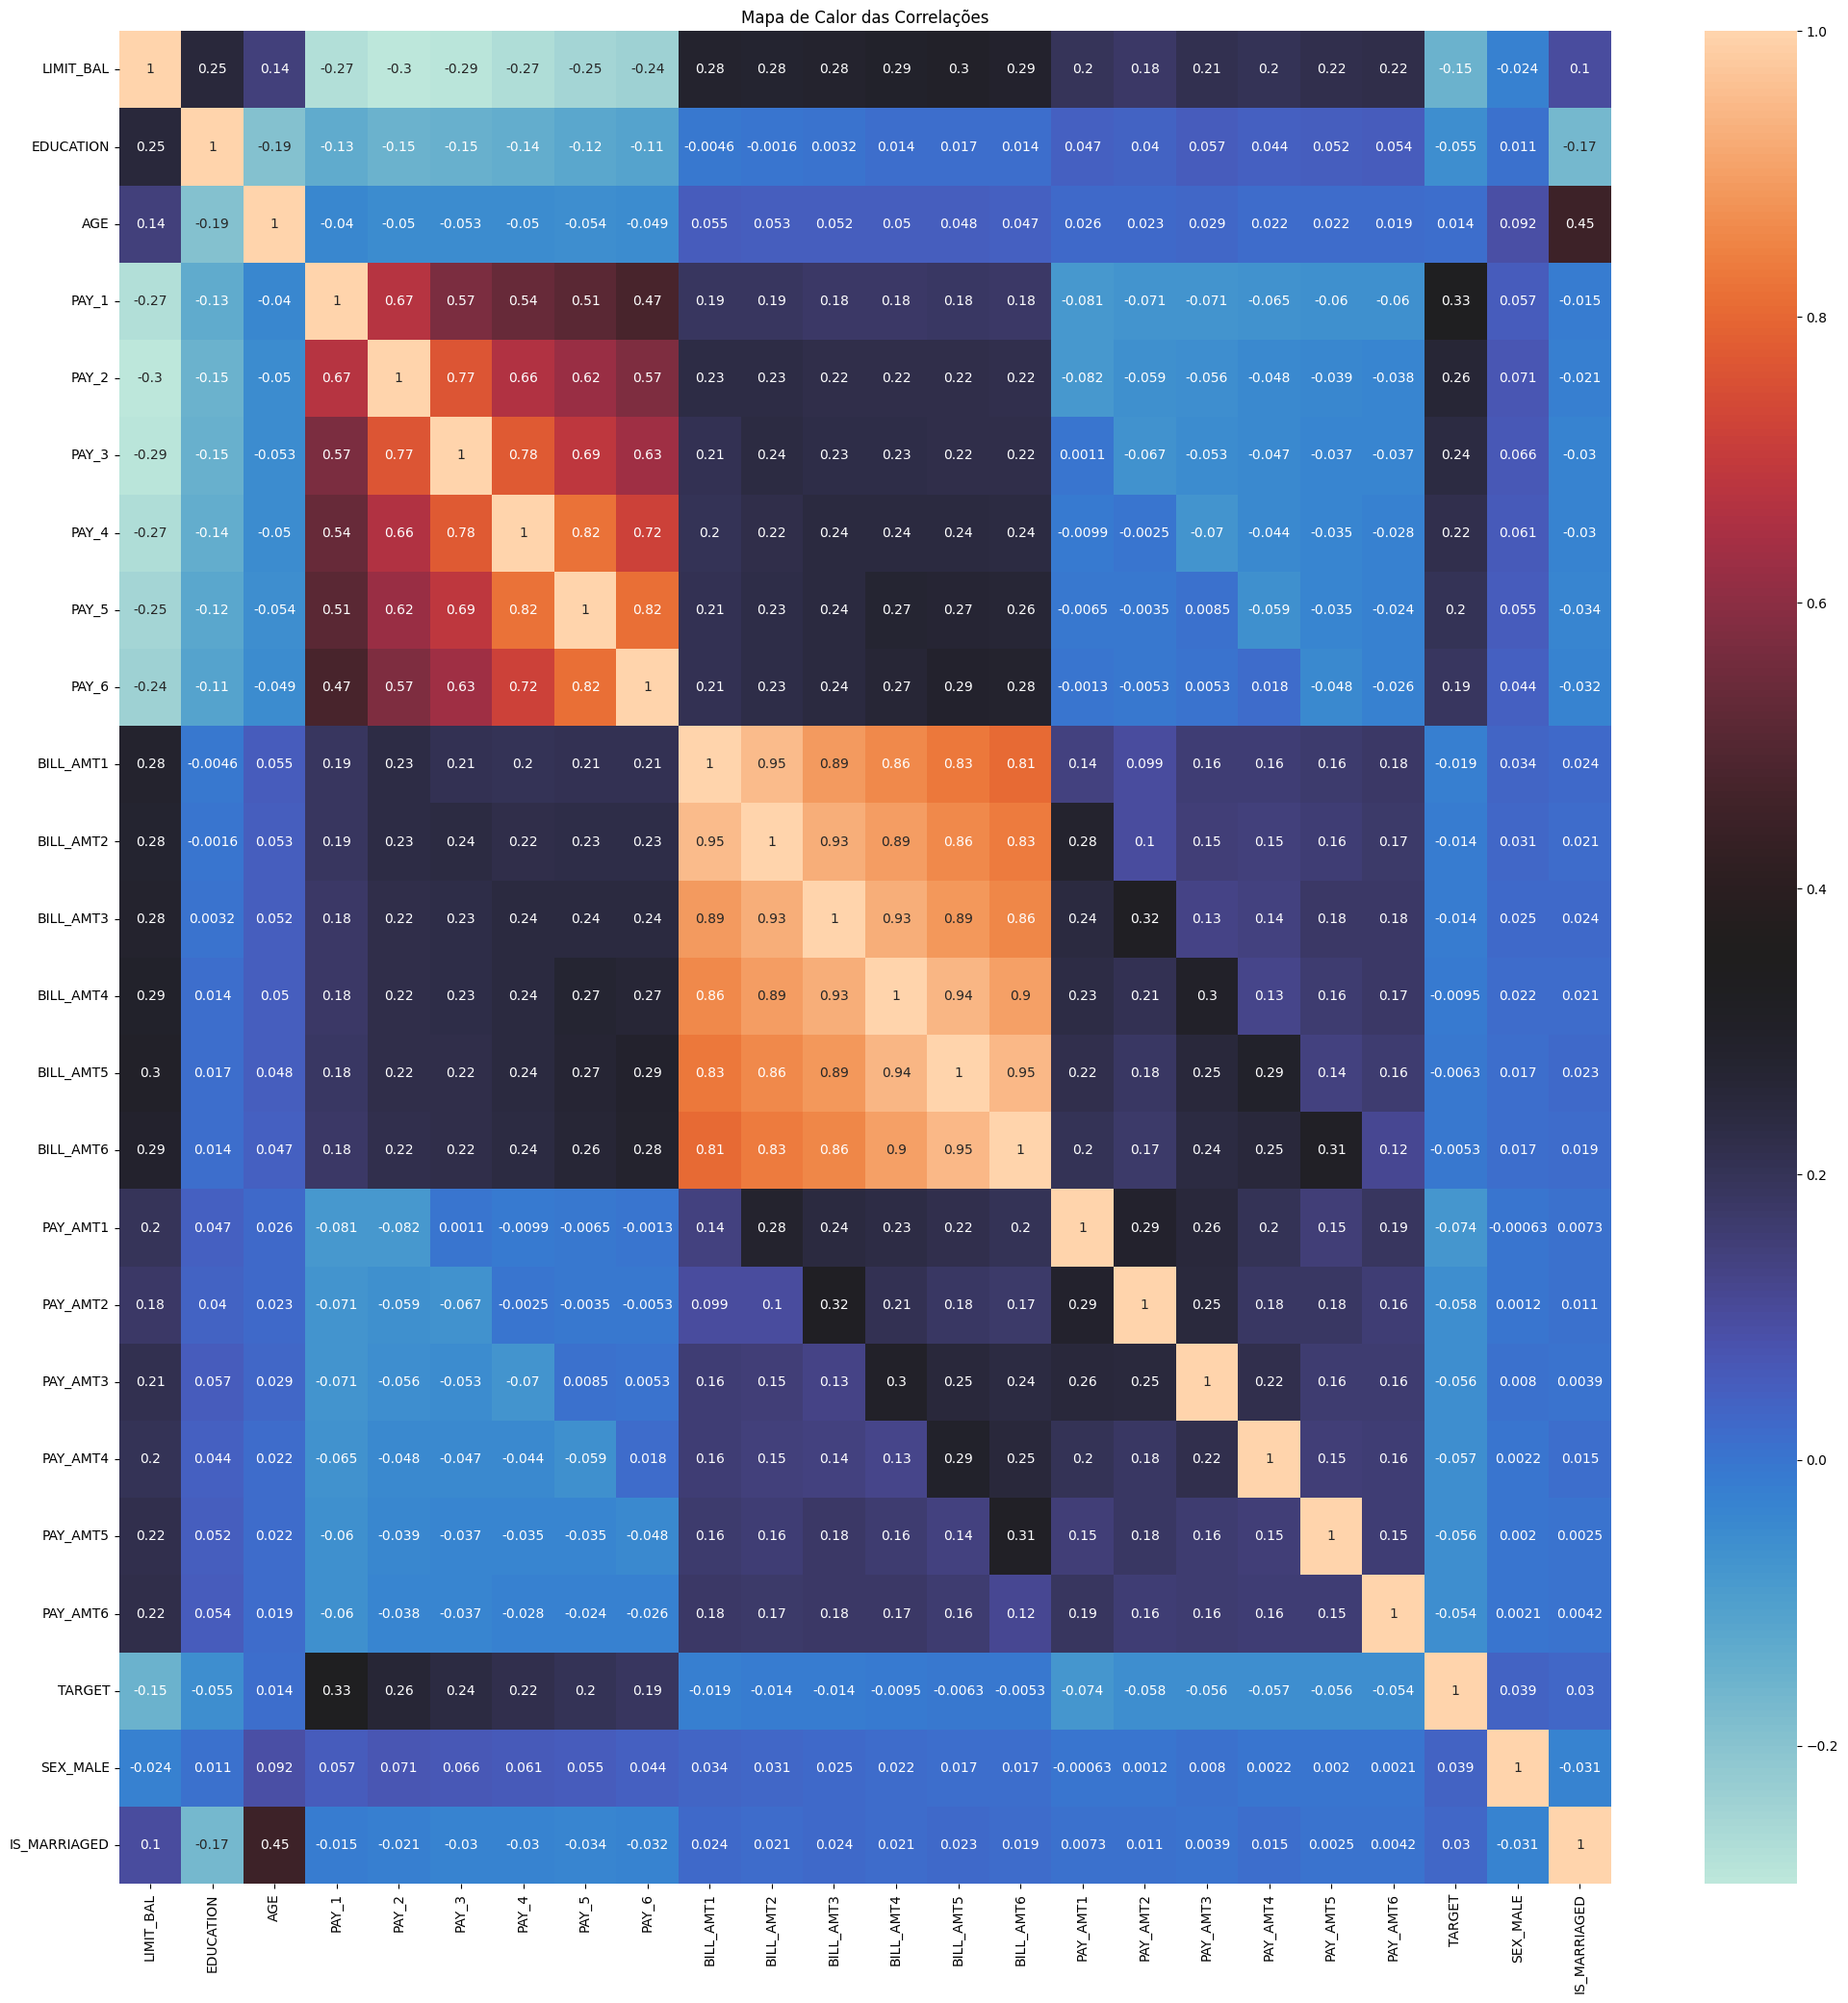


----- BANCO DE DADOS 1 ORIGINAL || CORRELAÇÃO DAS FEATURES COM O RÓTULO -----

PAY_1           0.326752
PAY_2           0.263992
PAY_3           0.235199
PAY_4           0.216265
PAY_5           0.204614
PAY_6           0.187331
SEX_MALE        0.039476
IS_MARRIAGED    0.030089
AGE             0.014109
BILL_AMT6      -0.005292
BILL_AMT5      -0.006279
BILL_AMT4      -0.009458
BILL_AMT3      -0.013637
BILL_AMT2      -0.013894
BILL_AMT1      -0.019322
PAY_AMT6       -0.053749
EDUCATION      -0.055366
PAY_AMT3       -0.055894
PAY_AMT5       -0.055991
PAY_AMT4       -0.056959
PAY_AMT2       -0.058363
PAY_AMT1       -0.074011
LIMIT_BAL      -0.153776
Name: TARGET, dtype: float64

----- BANCO DE DADOS 1 ORIGINAL || GRÁFICO DAS VARIÁVEIS SENSÍVEIS EM RELAÇÃO AO RÓTULO -----



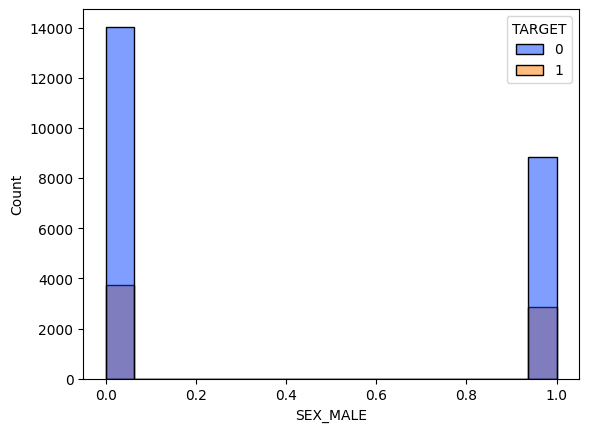

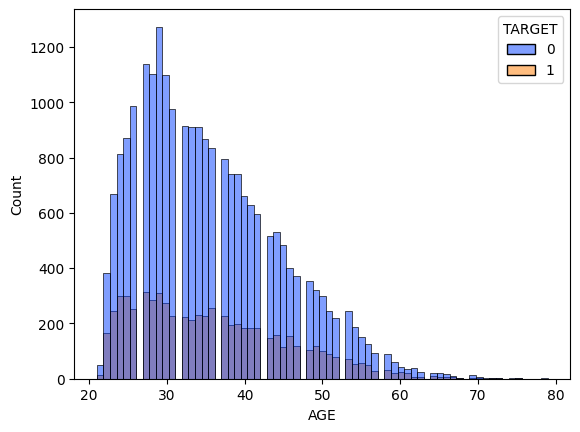

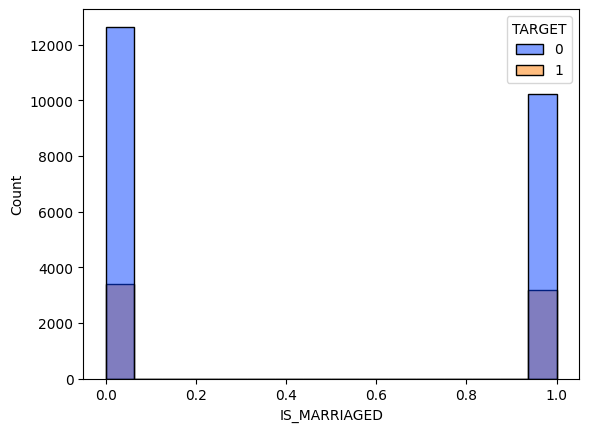


----- BANCO DE DADOS 1 ORIGINAL || SIGNIFICÂNCIA ESTATÍSTICA PARA DADOS DISCRETOS -----

DADO PESSOAL - Tabela de Contingência para SEX_MALE:
TARGET        0     1
SEX_MALE             
0         14033  3741
1          8847  2857
* Estatística Qui-Quadrado: 45.7441
* P-valor: 0.000000000013
* A associação é estatisticamente significativa (rejeitamos H₀).

DADO PESSOAL - Tabela de Contingência para IS_MARRIAGED:
TARGET            0     1
IS_MARRIAGED             
0             12644  3409
1             10236  3189
* Estatística Qui-Quadrado: 26.5428
* P-valor: 0.000000257758
* A associação é estatisticamente significativa (rejeitamos H₀).

Tabela de Contingência para EDUCATION:
TARGET         0     1
EDUCATION             
0           3640  1233
1          10695  3329
2           8545  2036
* Estatística Qui-Quadrado: 98.8162
* P-valor: 0.000000000000
* A associação é estatisticamente significativa (rejeitamos H₀).

Tabela de Contingência para PAY_1:
TARGET      0     1
PAY_1          

In [42]:
bases_avaliar = {
  'Orginal 1': {
    'dados': df1_original,
    'colunas_pessoais': ["SEX_MALE", "AGE", "IS_MARRIAGED"],
    'colunas_discretas': ['SEX_MALE', 'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'],
    'colunas_continuas': ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
          'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
          'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
  }
  # 'Orginal 2': {
  #   'dados': df2_original,
  #   'colunas_pessoais': ["SEX_MALE", "AGE", "IS_MARRIAGED"],
  #   'colunas_discretas': ['SEX_MALE', 'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'],
  #   'colunas_continuas': ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
  #         'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
  #         'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
  # },
  # 'Orginal 3': {
  #   'dados': df3_original,
  #   'colunas_pessoais': ["SEX_MALE", "AGE", "IS_MARRIAGED"],
  #   'colunas_discretas': ['SEX_MALE', 'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'],
  #   'colunas_continuas': ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
  #         'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
  #         'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
  # }
}

comparar_bases_de_dados(bases_avaliar)

# Modelos de machine learning

## Calculo do desempenho

In [43]:
%matplotlib inline

In [44]:
def metricas_matriz_de_confusao(cm):
    tn, fp, fn, tp = cm.ravel()

    total = tn + fp + fn + tp

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    selection_rate = (tp + fp) / total if total > 0 else 0

    return {
        "matriz_de_confusao": cm.tolist(),
        "true_positive_rate": tpr,
        "true_negative_rate": tnr,
        "false_positive_rate": fpr,
        "false_negative_rate": fnr,
        "selection_rate": selection_rate
    }

In [45]:
def desempenho_modelo(nome_base_de_dados, model, X_test, X_test_justica, y_pred, y_test, printar=False, matriz_de_confusao=False):
  desempenho = {}

  # Relatório de classificação
  if(printar):
    print(f"\n----- {nome_base_de_dados} || RELATÓRIO DE CLASSIFICAÇÃO -----\n")
    print(classification_report(y_test, y_pred))
  desempenho["relatorio_classificacao"] = classification_report(y_test, y_pred, output_dict=True)

  # Cálculo da AUC
  y_pred_proba = model.predict_proba(X_test)[:, 1]
  auc = roc_auc_score(y_test, y_pred_proba)
  desempenho['ROC_AUC'] = auc
  if(printar):
    print(f"ROC AUC: {auc:.4f}")

  # Matriz de Confusão
  cm = confusion_matrix(y_test, y_pred)
  desempenho["matriz_de_confusao"] = cm.tolist()
  if(matriz_de_confusao):
    print(f"\n----- {nome_base_de_dados} || MATRIZ DE CONFUSÃO -----\n")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['0', '1'],
                yticklabels=['0', '1'])
    plt.title('Matriz de Confusão')
    plt.ylabel('Rótulo Verdadeiro (True Label)')
    plt.xlabel('Rótulo Previsto (Predicted Label)')
    plt.show()

  # Para a variável SEX_MALE
  filtro_masculino = X_test_justica['SEX_MALE'] == 1
  y_test_masc = y_test[filtro_masculino]
  y_pred_masc = y_pred[filtro_masculino]
  cm_masc = confusion_matrix(y_test_masc, y_pred_masc)
  desempenho["SEX_MALE_1"] = metricas_matriz_de_confusao(cm_masc)

  filtro_feminino = X_test_justica['SEX_MALE'] == 0
  y_test_fem = y_test[filtro_feminino]
  y_pred_fem = y_pred[filtro_feminino]
  cm_fem = confusion_matrix(y_test_fem, y_pred_fem)
  desempenho["SEX_MALE_0"] = metricas_matriz_de_confusao(cm_fem)

  # Verificando a justiça do modelo
  if(printar):
    print(f"\n----- {nome_base_de_dados} || JUSTIÇA DO MODELO -----\n")

  df_results = pd.DataFrame({
    'Y_real': y_test,
    'Y_predito': y_pred,
    'SEX_MALE': X_test_justica['SEX_MALE']
  })

  # Separando os grupos
  group_female = (df_results['SEX_MALE'] == 0)
  group_male = (df_results['SEX_MALE'] == 1)

  # Métrica 1 - Demographic Parity (Selection Rate) - (Paridade estatística)
  selection_rate_female = df_results[group_female]['Y_predito'].mean()
  selection_rate_male = df_results[group_male]['Y_predito'].mean()

  demographic_parity_difference = selection_rate_female - selection_rate_male
  try:
      demographic_parity_ratio = selection_rate_female / selection_rate_male
  except ZeroDivisionError:
      demographic_parity_ratio = float('inf')

  if(printar):
      print("----- Demographic Parity (Selection Rate) -----")
      print(f"Selection Rate (Female): {selection_rate_female:.4f}")
      print(f"Selection Rate (Male):   {selection_rate_male:.4f}")
      print(f"Demographic Parity Difference: {demographic_parity_difference:.4f}")
      print(f"Demographic Parity Ratio:    {demographic_parity_ratio:.4f}\n")

  desempenho["demographic_parity"] = {
      "selection_rate_male": selection_rate_male,
      "selection_rate_female": selection_rate_female,
      "demographic_parity_difference": demographic_parity_difference,
      "demographic_parity_ratio": demographic_parity_ratio
  }

  # Metrica 2 - True Positive Rate - (Equal Opportunity)
  positives_real = df_results[df_results['Y_real'] == 1]
  tpr_female = positives_real[positives_real['SEX_MALE'] == 0]['Y_predito'].mean()
  tpr_male = positives_real[positives_real['SEX_MALE'] == 1]['Y_predito'].mean()

  true_positive_rate_difference = tpr_female - tpr_male
  try:
      true_positive_rate_ratio = tpr_female / tpr_male
  except ZeroDivisionError:
      true_positive_rate_ratio = float('inf')

  if(printar):
      print("----- True Positive Rate (Equal Opportunity) -----")
      print(f"True Positive Rate (Female): {tpr_female:.4f}")
      print(f"True Positive Rate (Male):   {tpr_male:.4f}")
      print(f"True Positive Rate Difference: {true_positive_rate_difference:.4f}")
      print(f"True Positive Rate Ratio:      {true_positive_rate_ratio:.4f}\n")

  desempenho["true_positive_rate"] = {
      "true_positive_rate_male": tpr_male,
      "true_positive_rate_female": tpr_female,
      "true_positive_rate_difference": true_positive_rate_difference,
      "true_positive_rate_ratio": true_positive_rate_ratio
  }

  # Metrica 3 - False Positive Rate
  negatives_real = df_results[df_results['Y_real'] == 0]
  fpr_female = negatives_real[negatives_real['SEX_MALE'] == 0]['Y_predito'].mean()
  fpr_male = negatives_real[negatives_real['SEX_MALE'] == 1]['Y_predito'].mean()

  fpr_difference = fpr_female - fpr_male
  try:
      fpr_ratio = fpr_female / fpr_male
  except ZeroDivisionError:
      fpr_ratio = float('inf')

  if(printar):
      print("----- False Positive Rate -----")
      print(f"False Positive Rate (Female): {fpr_female:.4f}")
      print(f"False Positive Rate (Male):   {fpr_male:.4f}")
      print(f"False Positive Rate Difference: {fpr_difference:.4f}")
      print(f"False Positive Rate Ratio:      {fpr_ratio:.4f}\n")

  desempenho["false_positive_rate"] = {
      "false_positive_rate_male": fpr_male,
      "false_positive_rate_female": fpr_female,
      "false_positive_rate_difference": fpr_difference,
      "false_positive_rate_ratio": fpr_ratio
  }

  # Metrica 4 - False Negative Rate
  fnr_female = 1 - tpr_female
  fnr_male = 1 - tpr_male

  fnr_difference = fnr_female - fnr_male
  try:
      fnr_ratio = fnr_female / fnr_male
  except ZeroDivisionError:
      fnr_ratio = float('inf')

  if(printar):
      print("----- False Negative Rate -----")
      print(f"False Negative Rate (Female): {fnr_female:.4f}")
      print(f"False Negative Rate (Male):   {fnr_male:.4f}")
      print(f"False Negative Rate Difference: {fnr_difference:.4f}")
      print(f"False Negative Rate Ratio:      {fnr_ratio:.4f}\n")

  desempenho["false_negative_rate"] = {
      "false_negative_rate_male": fnr_male,
      "false_negative_rate_female": fnr_female,
      "false_negative_rate_difference": fnr_difference,
      "false_negative_rate_ratio": fnr_ratio
  }

  # Metrica 5 - Predictive Parity (Precision)
  positives_predicted = df_results[df_results['Y_predito'] == 1]
  precision_female = positives_predicted[positives_predicted['SEX_MALE'] == 0]['Y_real'].mean()
  precision_male = positives_predicted[positives_predicted['SEX_MALE'] == 1]['Y_real'].mean()

  predictive_parity_difference = precision_female - precision_male
  try:
      predictive_parity_ratio = precision_female / precision_male
  except ZeroDivisionError:
      predictive_parity_ratio = float('inf')

  if(printar):
      print("----- Predictive Parity (Precision) -----")
      print(f"Precision (Female): {precision_female:.4f}")
      print(f"Precision (Male):   {precision_male:.4f}")
      print(f"Predictive Parity Difference: {predictive_parity_difference:.4f}")
      print(f"Predictive Parity Ratio:      {predictive_parity_ratio:.4f}\n")

  desempenho["predictive_parity"] = {
      "precision_male": precision_male,
      "precision_female": precision_female,
      "predictive_parity_difference": predictive_parity_difference,
      "predictive_parity_ratio": predictive_parity_ratio
  }

  # Metrica 6 - Equalized Odds
  equalized_odds_difference = max(abs(tpr_female - tpr_male), abs(fpr_female - fpr_male))
  try:
      tpr_r = tpr_female / tpr_male
      fpr_r = fpr_female / fpr_male
      equalized_odds_ratio = min(tpr_r, fpr_r)
  except ZeroDivisionError:
      equalized_odds_ratio = 0 # If one rate is 0, the minimum ratio is 0.

  if(printar):
      print("----- Equalized Odds -----")
      print(f"Equalized Odds Difference (max of TPR/FPR diffs): {equalized_odds_difference:.4f}")
      print(f"Equalized Odds Ratio (min of TPR/FPR ratios):    {equalized_odds_ratio:.4f}\n")

  desempenho["equalized_odds"] = {
      "equalized_odds_difference": equalized_odds_difference,
      "equalized_odds_ratio": equalized_odds_ratio,
  }

  return(desempenho)

## Gráfico shap

In [46]:
def fazer_grafico_shap(nome_base_de_dados, trained_model_pipeline, X_test):
    print(f"\n----- {nome_base_de_dados} || GRÁFICO SHAP -----\n")
    model = trained_model_pipeline.named_steps['classifier']

    explainer = shap.TreeExplainer(model)

    # Calculo dos valores SHAP
    explanation = explainer(X_test)

    # Selecionando os valores para a classe positiva (1)
    shap_values_class1 = explanation.values

    df_shap = pd.DataFrame(shap_values_class1, columns=X_test.columns)

    df_features = X_test.reset_index(drop=True)

    df_long = pd.melt(df_shap, var_name='Feature', value_name='SHAP Value')

    sensitive_col = np.tile(df_features['SEX_MALE'].values, len(X_test.columns))
    df_long['SEX_MALE'] = sensitive_col

    # Criação do Gráfico de Violino Dividido
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(24, 6))

    sns.violinplot(
        data=df_long,
        x='Feature',
        y='SHAP Value',
        hue='SEX_MALE',    # A coluna que vai dividir
        split=True,        # Divide no meio
        inner='quart',     # Mostra os quartis
        palette={0: '#4c72b0', 1: '#dd8452'}
    )

    # Configurações do gráfico
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(rotation=45, ha='right')
    plt.title('Distribuição dos Valores SHAP por Feature e Gênero', fontsize=16)
    plt.xlabel('')

    # Configuração da legenda
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=['Feminino', 'Masculino'], title='Demographic Group')

    plt.tight_layout()
    plt.show()

## Modelos brutos

### Random Forest

In [47]:
def random_forest(nome_base_de_dados, rotulo, parametros_de_treino, X_train, X_test, y_train, y_test, printar=False, matriz_de_confusao=False, grafico_features=False, grafico_shap=False, pesos=False, pesos_modelo=None, X_justica=False, X_test_justica=None, printar_dados=False):
  desempenho = {}

  if(pesos):
    pesos_treino = pesos_modelo.loc[X_train.index]
  else:
    pesos_treino = None

  # Pré-processamento - LIM_BAL, BILL_AMT, PAY_AMT
  numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
  print("Features numéricas: ", numerical_features)

  # Aplicando Standarlization nas colunas numéricas
  preprocessor = ColumnTransformer(
      transformers=[
          ('num', StandardScaler(), numerical_features)
      ],
      remainder='passthrough',
      verbose_feature_names_out=False
  )

  log_reg_model = RandomForestClassifier(**parametros_de_treino)

  model_pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', log_reg_model)
  ])

  # Dados antes da padronização
  if(printar_dados):
    print(f"\n----- {base_de_dados.name} || AMOSTRA DOS DADOS ANTES DA PADRONIZAÇÃO -----\n")
    print(X_train.head())

  # Ajustar o pré-processador e transformar os dados para visualização
  X_train_processed = preprocessor.fit_transform(X_train)

  # Recria a lista de colunas na ordem correta após a transformação
  processed_columns = preprocessor.get_feature_names_out()
  X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_columns, index=X_train.index)

  if(printar_dados):
    print(f"\n----- {base_de_dados.name} || AMOSTRA DOS DADOS DEPOIS DA PADRONIZAÇÃO -----\n")
    print(X_train_processed_df.head())

  fit_params = {}
  if pesos and pesos_modelo is not None:
      pesos_treino = pesos_modelo.loc[X_train.index]
      fit_params['classifier__sample_weight'] = pesos_treino

  model_pipeline.fit(X_train, y_train, **fit_params)
  y_pred = model_pipeline.predict(X_test)

  # Caso não tenha um x específico para justiça, usa o próprio x_test
  if(X_justica == False):
    X_test_justica = X_test

  desempenho = desempenho_modelo(nome_base_de_dados, model_pipeline, X_test, X_test_justica, y_pred, y_test, printar=printar, matriz_de_confusao=matriz_de_confusao)

  # Importância das features
  feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

  feature_importances = pd.Series(
      model_pipeline.named_steps['classifier'].feature_importances_,
      index=feature_names
  ).sort_values(ascending=False)

  desempenho["importancia_das_features"] = feature_importances

  # Importância das features
  if(printar):
    print(f"\n----- {nome_base_de_dados} || IMPORTÂNCIA DAS FEATURES -----\n")
    print(feature_importances)

  # Gráfico com a importância das features
  if(grafico_features):
    print(f"\n----- {nome_base_de_dados} || GRÁFICO DA IMPORTÂNCIA DAS FEATURES -----\n")
    plt.figure(figsize=(8, 6))
    feature_importances.plot(kind='bar')
    plt.title('Importância das features para TARGET')
    plt.ylabel('Importância')
    plt.xlabel('Features')
    plt.tight_layout()
    plt.show()

  # Criação do gráfioc shap
  if(grafico_shap):
    fazer_grafico_shap(nome_base_de_dados, model_pipeline, X_test)

  return(model_pipeline, desempenho)

### Regressão logística

In [48]:
def regressao_logistica(nome_base_de_dados, rotulo, parametros_de_treino, X_train, X_test, y_train, y_test, printar=False, matriz_de_confusao=False, grafico_features=False, grafico_shap=False, pesos=False, pesos_modelo=None, X_justica=False, X_test_justica=None, printar_dados=False):
  desempenho = {}

  if(pesos):
    pesos_treino = pesos_modelo.loc[X_train.index]
  else:
    pesos_treino = None

  # Pré-processamento - LIM_BAL, BILL_AMT, PAY_AMT
  numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
  print("Features numéricas: ", numerical_features)

  # Aplicando Standarlization nas colunas numéricas
  preprocessor = ColumnTransformer(
      transformers=[
          ('num', StandardScaler(), numerical_features)
      ],
      remainder='passthrough',
      verbose_feature_names_out=False
  )

  log_reg_model = LogisticRegression(**parametros_de_treino)

  model_pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', log_reg_model)
  ])

  # Dados antes da padronização
  if(printar_dados):
    print(f"\n----- {base_de_dados.name} || AMOSTRA DOS DADOS ANTES DA PADRONIZAÇÃO -----\n")
    print(X_train.head())

  # Ajustar o pré-processador e transformar os dados para visualização
  X_train_processed = preprocessor.fit_transform(X_train)

  # Recria a lista de colunas na ordem correta após a transformação
  processed_columns = preprocessor.get_feature_names_out()
  X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_columns, index=X_train.index)

  if(printar_dados):
    print(f"\n----- {base_de_dados.name} || AMOSTRA DOS DADOS DEPOIS DA PADRONIZAÇÃO -----\n")
    print(X_train_processed_df.head())

  fit_params = {}
  if pesos and pesos_modelo is not None:
      pesos_treino = pesos_modelo.loc[X_train.index]
      fit_params['classifier__sample_weight'] = pesos_treino

  model_pipeline.fit(X_train, y_train, **fit_params)
  y_pred = model_pipeline.predict(X_test)

  # Caso não tenha um x específico para justiça, usa o próprio x_test
  if(X_justica == False):
    X_test_justica = X_test

  desempenho = desempenho_modelo(nome_base_de_dados, model_pipeline, X_test, X_test_justica, y_pred, y_test, printar=printar, matriz_de_confusao=matriz_de_confusao)

  # Importância das features

  # Extrair componentes do pipeline treinado
  logistic_model = model_pipeline.named_steps['classifier']
  preprocessor_fitted = model_pipeline.named_steps['preprocessor']

  # Extrair coeficientes e nomes das features
  coefficients = logistic_model.coef_[0]
  feature_names = preprocessor_fitted.get_feature_names_out()

  # Criar e formatar o DataFrame de importância
  feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
  feature_importance['Magnitude'] = feature_importance['Importance'].abs()
  sorted_importance = feature_importance.sort_values(by='Magnitude', ascending=False)
  sorted_importance['Clean_Feature'] = sorted_importance['Feature'].str.replace(r'^(num__|remainder__)', '', regex=True)

  # Formatar a coluna Magnitude como string
  magnitude_str = sorted_importance['Magnitude'].map('{:.6f}'.format)

  # Aplicar a condição para indicar se o coeficiente é negativo
  condition = sorted_importance['Importance'] < 0
  value_if_true = magnitude_str + " (Negativo)"
  value_if_false = magnitude_str
  sorted_importance['Formatted_Importance'] = np.where(condition, value_if_true, value_if_false)

  # Imprimir a saída formatada
  output_string = sorted_importance[['Clean_Feature', 'Formatted_Importance']].to_string(
      index=False, header=False,
      formatters={'Clean_Feature': '{:<20}'.format, 'Formatted_Importance': '{:<25}'.format}
  )
  if(printar):
    print(f"\n----- {nome_base_de_dados} || IMPORTÂNCIA DAS FEATURES -----\n")
    print(output_string)

  desempenho["importancia_das_features"] = output_string

  return(model_pipeline, desempenho)

### Perceptron

In [49]:
def perceptron(nome_base_de_dados, rotulo, parametros_de_treino, X_train, X_test, y_train, y_test, printar=False, matriz_de_confusao=False, grafico_features=False, grafico_shap=False, pesos=False, pesos_modelo=None, X_justica=False, X_test_justica=None, printar_dados=False):
  desempenho = {}

  if(pesos):
    pesos_treino = pesos_modelo.loc[X_train.index]
  else:
    pesos_treino = None

  # Pré-processamento - LIM_BAL, BILL_AMT, PAY_AMT
  numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
  print("Features numéricas: ", numerical_features)

  # Aplicando Standarlization nas colunas numéricas
  preprocessor = ColumnTransformer(
      transformers=[
          ('num', StandardScaler(), numerical_features)
      ],
      remainder='passthrough',
      verbose_feature_names_out=False
  )

  # Instanciando o modelo
  base_model = Perceptron(**parametros_de_treino) # eta=0.1, n_iter=20, random_state=seed
  # Para obter a probabilidade da previsão
  calibrated_model = CalibratedClassifierCV(base_model, cv=5, method='sigmoid') # eta=0.1, n_iter=20, random_state=seed
  log_reg_model = calibrated_model

  model_pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', log_reg_model)
  ])

  # Dados antes da padronização
  if(printar_dados):
    print(f"\n----- {base_de_dados.name} || AMOSTRA DOS DADOS ANTES DA PADRONIZAÇÃO -----\n")
    print(X_train.head())

  # Ajustar o pré-processador e transformar os dados para visualização
  X_train_processed = preprocessor.fit_transform(X_train)

  # Recria a lista de colunas na ordem correta após a transformação
  processed_columns = preprocessor.get_feature_names_out()
  X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_columns, index=X_train.index)

  if(printar_dados):
    print(f"\n----- {base_de_dados.name} || AMOSTRA DOS DADOS DEPOIS DA PADRONIZAÇÃO -----\n")
    print(X_train_processed_df.head())

  fit_params = {}
  if pesos and pesos_modelo is not None:
      pesos_treino = pesos_modelo.loc[X_train.index]
      fit_params['classifier__sample_weight'] = pesos_treino

  model_pipeline.fit(X_train, y_train, **fit_params)
  y_pred = model_pipeline.predict(X_test)

  # Caso não tenha um x específico para justiça, usa o próprio x_test
  if(X_justica == False):
    X_test_justica = X_test

  desempenho = desempenho_modelo(nome_base_de_dados, model_pipeline, X_test, X_test_justica, y_pred, y_test, printar=printar, matriz_de_confusao=matriz_de_confusao)

  # Importância das features

  # Treinando um outro modelo
  inspection_pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', base_model)
  ])

  # Treinamos este pipeline nos mesmos dados
  inspection_pipeline.fit(X_train, y_train)

  # Extrair componentes do pipeline treinado
  trained_linear_model = inspection_pipeline.named_steps['classifier']
  preprocessor_fitted = inspection_pipeline.named_steps['preprocessor']

  # Extrair coeficientes e nomes das features
  coefficients = trained_linear_model.coef_[0]
  feature_names = preprocessor_fitted.get_feature_names_out()

  # Criar e formatar o DataFrame de importância
  feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
  feature_importance['Magnitude'] = feature_importance['Importance'].abs()
  sorted_importance = feature_importance.sort_values(by='Magnitude', ascending=False)
  sorted_importance['Clean_Feature'] = sorted_importance['Feature'].str.replace(r'^(num__|remainder__)', '', regex=True)

  # Formatar a coluna Magnitude como string
  magnitude_str = sorted_importance['Magnitude'].map('{:.6f}'.format)

  # Aplicar a condição para indicar se o coeficiente é negativo
  condition = sorted_importance['Importance'] < 0
  value_if_true = magnitude_str + " (Negativo)"
  value_if_false = magnitude_str
  sorted_importance['Formatted_Importance'] = np.where(condition, value_if_true, value_if_false)

  # Imprimir a saída formatada
  output_string = sorted_importance[['Clean_Feature', 'Formatted_Importance']].to_string(
      index=False, header=False,
      formatters={'Clean_Feature': '{:<20}'.format, 'Formatted_Importance': '{:<25}'.format}
  )
  if(printar):
    print(f"\n----- {nome_base_de_dados} || IMPORTÂNCIA DAS FEATURES -----\n")
    print(output_string)

  desempenho["importancia_das_features"] = output_string

  return(model_pipeline, desempenho)

### XGBoost

In [50]:
def xgboost(nome_base_de_dados, rotulo, parametros_de_treino, X_train, X_test, y_train, y_test, printar=False, matriz_de_confusao=False, grafico_features=False, grafico_shap=False, pesos=False, pesos_modelo=None, X_justica=False, X_test_justica=None, printar_dados=False):
  desempenho = {}

  if(pesos):
    pesos_treino = pesos_modelo.loc[X_train.index]
  else:
    pesos_treino = None

  # Pré-processamento - LIM_BAL, BILL_AMT, PAY_AMT
  numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
  print("Features numéricas: ", numerical_features)

  # Aplicando Standarlization nas colunas numéricas
  preprocessor = ColumnTransformer(
      transformers=[
          ('num', StandardScaler(), numerical_features)
      ],
      remainder='passthrough',
      verbose_feature_names_out=False
  )

  log_reg_model = xgb.XGBClassifier(**parametros_de_treino)

  model_pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', log_reg_model)
  ])

  # Dados antes da padronização
  if(printar_dados):
    print(f"\n----- {base_de_dados.name} || AMOSTRA DOS DADOS ANTES DA PADRONIZAÇÃO -----\n")
    print(X_train.head())

  # Ajustar o pré-processador e transformar os dados para visualização
  X_train_processed = preprocessor.fit_transform(X_train)

  # Recria a lista de colunas na ordem correta após a transformação
  processed_columns = preprocessor.get_feature_names_out()
  X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_columns, index=X_train.index)

  if(printar_dados):
    print(f"\n----- {base_de_dados.name} || AMOSTRA DOS DADOS DEPOIS DA PADRONIZAÇÃO -----\n")
    print(X_train_processed_df.head())

  fit_params = {}
  if pesos and pesos_modelo is not None:
      pesos_treino = pesos_modelo.loc[X_train.index]
      fit_params['classifier__sample_weight'] = pesos_treino

  model_pipeline.fit(X_train, y_train, **fit_params)
  y_pred = model_pipeline.predict(X_test)

  # Caso não tenha um x específico para justiça, usa o próprio x_test
  if(X_justica == False):
    X_test_justica = X_test

  desempenho = desempenho_modelo(nome_base_de_dados, model_pipeline, X_test, X_test_justica, y_pred, y_test, printar=printar, matriz_de_confusao=matriz_de_confusao)

  # Importância das features
  feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

  feature_importances = pd.Series(
      model_pipeline.named_steps['classifier'].feature_importances_,
      index=feature_names
  ).sort_values(ascending=False)

  desempenho["importancia_das_features"] = feature_importances

  # Importância das features
  if(printar):
    print(f"\n----- {nome_base_de_dados} || IMPORTÂNCIA DAS FEATURES -----\n")
    print(feature_importances)

  # Gráfico com a importância das features
  if(grafico_features):
    print(f"\n----- {nome_base_de_dados} || GRÁFICO DA IMPORTÂNCIA DAS FEATURES -----\n")
    plt.figure(figsize=(8, 6))
    feature_importances.plot(kind='bar')
    plt.title('Importância das features para TARGET')
    plt.ylabel('Importância')
    plt.xlabel('Features')
    plt.tight_layout()
    plt.show()

  # Criação do gráfioc shap
  if(grafico_shap):
    fazer_grafico_shap(nome_base_de_dados, model_pipeline, X_test)

  return(model_pipeline, desempenho)

### Teste modelos brutos

In [51]:
%matplotlib inline

Features numéricas:  ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

----- BANCO DE DADOS 1 ORIGINAL || AMOSTRA DOS DADOS ANTES DA PADRONIZAÇÃO -----

       LIMIT_BAL  EDUCATION  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  \
7461     90000.0          2   52      0      0      0      0      0      0   
4664    120000.0          2   24      0      0      0      0      0      0   
24334    30000.0          1   38      0      0     -1     -1     -1     -1   
13218    20000.0          2   23      2      0      0      2      2      2   
8       140000.0          0   28      0      0      2      0      0      0   

       BILL_AMT1  ...  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
7461     91656.0  ...    27751.0    29923.0    5110.0    2000.0    3000.0   
4664     78304.0  ...    84404.0    86096.0    2900.0    3850.0    3000.0   
24334    18526.0  ...     1680.0

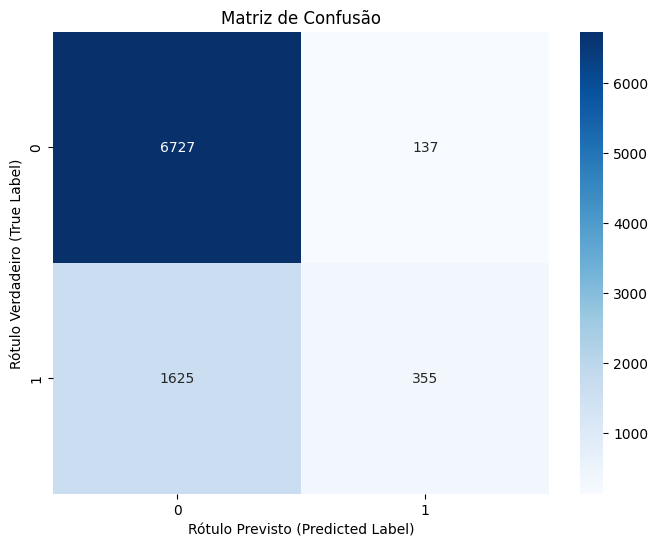


----- BANCO DE DADOS 1 ORIGINAL || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Female): 0.0507
Selection Rate (Male):   0.0635
Demographic Parity Difference: -0.0128
Demographic Parity Ratio:    0.7982

----- True Positive Rate (Equal Opportunity) -----
True Positive Rate (Female): 0.1730
True Positive Rate (Male):   0.1881
True Positive Rate Difference: -0.0151
True Positive Rate Ratio:      0.9197

----- False Positive Rate -----
False Positive Rate (Female): 0.0174
False Positive Rate (Male):   0.0241
False Positive Rate Difference: -0.0067
False Positive Rate Ratio:      0.7211

----- False Negative Rate -----
False Negative Rate (Female): 0.8270
False Negative Rate (Male):   0.8119
False Negative Rate Difference: 0.0151
False Negative Rate Ratio:      1.0186

----- Predictive Parity (Precision) -----
Precision (Female): 0.7299
Precision (Male):   0.7110
Predictive Parity Difference: 0.0189
Predictive Parity Ratio:      1.0266

----- Eq

In [52]:
testar = True
if(testar):
  # funcao_modelo = regressao_logistica
  funcao_modelo = perceptron
  # funcao_modelo = random_forest
  # funcao_modelo = xgboost

  base_de_dados = df1_original
  funcao_parametros = {}

  # TREINANDO UM MODELO

  # Obtendo as features e o rótulo
  X = base_de_dados.drop('TARGET', axis=1)
  y = base_de_dados['TARGET']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

  dataset_treino = pd.concat([X_train, y_train], axis=1)
  dataset_teste = pd.concat([X_test, y_test], axis=1)

  dataset_treino.to_csv('dataset_treino.csv', index=False)
  dataset_teste.to_csv('dataset_teste.csv', index=False)

  # Parâmetros de treino
  parametros_de_treino_regressao_logistica = {
      'max_iter': 1000,
      'random_state': seed,
      'penalty': 'l2',
      'solver': 'lbfgs',
      'C': 1
  }

  parametros_de_treino_perceptron = {
      'eta0': 0.1,
      'max_iter': 200,
      'random_state': seed
  }

  parametros_de_treino_random_forest = {
      'n_estimators': 100,
      'max_depth': 10,
      'random_state': seed
  }
  parametros_de_treino_xgboost = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': seed,
    'colsample_bytree': 1.0,
    'learning_rate': 0.1,
    'max_depth': 5,
    'n_estimators': 100,
    'subsample': 0.8,
  }

  parametros_selecionados = None
  if funcao_modelo == regressao_logistica:
      parametros_selecionados = parametros_de_treino_regressao_logistica
  elif funcao_modelo == perceptron:
      parametros_selecionados = parametros_de_treino_perceptron
  elif funcao_modelo == random_forest:
      parametros_selecionados = parametros_de_treino_random_forest
  elif funcao_modelo == xgboost:
      parametros_selecionados = parametros_de_treino_xgboost

  # Parâmetros gerais
  funcao_parametros['nome_base_de_dados'] = base_de_dados.name
  funcao_parametros['parametros_de_treino'] = parametros_selecionados
  funcao_parametros['rotulo'] = 'TARGET'
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test
  funcao_parametros['printar'] = True
  funcao_parametros['printar_dados'] = True
  funcao_parametros['matriz_de_confusao'] = True
  funcao_parametros['grafico_shap'] = False

  _, desempenho = funcao_modelo(**funcao_parametros)

### Comparando as bases de dados (Random Forest)

In [53]:
parametros_de_treino_regressao_logistica = {
    'max_iter': 1000,
    'random_state': seed
}

parametros_de_treino_random_forest = {
    'n_estimators': 100,
    'max_depth': 10,
    'random_state': seed
}

parametros_de_treino_perceptron = {
    'eta0': 0.1,
    'max_iter': 200,
    'random_state': seed
}

def treinar_modelo(base_de_dados, funcao_modelo, funcao_parametros):
    # Obtendo as features e o rótulo
    X = base_de_dados.drop('TARGET', axis=1)
    y = base_de_dados['TARGET']

    # Separando os dados 70% treino e 30% teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Parâmetros gerais
    funcao_parametros['nome_base_de_dados'] = base_de_dados.name
    funcao_parametros['rotulo'] = 'TARGET'
    funcao_parametros['X_train'] = X_train
    funcao_parametros['X_test'] = X_test
    funcao_parametros['y_train'] = y_train
    funcao_parametros['y_test'] = y_test

    _, desempenho = funcao_modelo(**funcao_parametros)

    return(desempenho)

In [54]:
# parametros = {}
# parametros['parametros_de_treino'] = parametros_de_treino_random_forest

# desempenho_random_forest = {}
# desempenho_random_forest["original"] = treinar_modelo(df_original_balanceado, random_forest, parametros.copy())
# desempenho_random_forest["enviesado_simples"] = treinar_modelo(df_enviesado_simples_balanceado, random_forest, parametros.copy())
# desempenho_random_forest["enviesado_smotenc"] = treinar_modelo(df_enviesado_smotenc_balanceado, random_forest, parametros.copy())
# desempenho_random_forest["original_discretizado"] = treinar_modelo(df_original_discretizado_balanceado, random_forest, parametros.copy())

In [55]:
# def get_nested_value(data_dict, path, default=float('nan')):
#     """Navega em um dicionário aninhado de forma segura."""
#     keys = path.split('.')
#     current_level = data_dict
#     for key in keys:
#         try:
#             current_level = current_level[key]
#         except (KeyError, TypeError):
#             try:
#                 alt_key = key + '.0'
#                 current_level = current_level[alt_key]
#             except (KeyError, TypeError):
#                 return default
#     return current_level

# # Configuração da tabela

# models_to_compare = [
#     'original',
#     'original_discretizado',
#     'enviesado_simples',
#     'enviesado_smotenc'
# ]

# single_value_metrics = {
#     'Acurácia': 'relatorio_classificacao.accuracy',
#     'Dif. Paridade Estatística': 'paridade_estatistica.diferenca_de_paridade_estatistica',
#     'Dif. Igualdade Oportunidade': 'igualdade_oportunidade.diferenca_de_igualdade',
#     'Dif. Paridade Preditiva': 'paridade_preditiva.diferenca_de_paridade_preditiva',
# }

# num_features = 23

# table_data = []
# headers = ["Métrica / Feature"] + models_to_compare

# for metric_name, path in single_value_metrics.items():
#     row = [metric_name]
#     for model in models_to_compare:
#         value = get_nested_value(desempenho_random_forest[model], path)
#         if "Dif." in metric_name:
#             row.append(f"{abs(value):.4f}")
#         else:
#             row.append(f"{value:.4f}")
#     table_data.append(row)

# # Colocando uma linha
# separator = ['-' * 20] + ['-' * (len(h) + 2) for h in headers[1:]]
# table_data.append(separator)

# # Extrair e formatar as features mais importantes
# feature_data = {}
# for model in models_to_compare:
#     feature_series = desempenho_random_forest[model]['importancia_das_features']
#     top_features = feature_series.head(num_features)
#     feature_data[model] = [f"({val:.4f}) {name}" for name, val in top_features.items()]

# # Construção das linhas
# for i in range(num_features):
#     row = [f"Top Feature {i+1}"]
#     for model in models_to_compare:
#         row.append(feature_data[model][i])
#     table_data.append(row)

# print("--- Tabela Comparativa de Desempenho, Justiça e Features ---\n")
# print(tabulate(table_data, headers=headers, tablefmt="psql"))

## Grid Search + Cross Validation

### Random forest: Grid Search + Cross Validation

In [56]:
def random_forest_GSCV(param_grid, preprocessor, cv_n_splits, nome_base_de_dados, X_train, X_test, y_train, y_test, printar=False, matriz_de_confusao=False, grafico_features=False, grafico_shap=False, pesos=False, pesos_modelo=None, X_justica=False, X_test_justica=None, printar_dados=False):
  desempenho = {}

  pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', RandomForestClassifier())
  ])

  cv_splitter = StratifiedKFold(n_splits=cv_n_splits, shuffle=True, random_state=seed)
  grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1_macro', cv=cv_splitter, n_jobs=-1, verbose=0)

  fit_params = {}
  if pesos and pesos_modelo is not None:
      pesos_treino = pesos_modelo.loc[X_train.index]
      fit_params['classifier__sample_weight'] = pesos_treino

  grid_search.fit(X_train, y_train, **fit_params)

  best_model = grid_search.best_estimator_
  y_pred = best_model.predict(X_test)

  if(X_justica == False):
    X_test_justica = X_test

  if(grafico_shap):
    fazer_grafico_shap(nome_base_de_dados, best_model, X_test)

  desempenho = desempenho_modelo(nome_base_de_dados, best_model, X_test, X_test_justica, y_pred, y_test, printar=printar, matriz_de_confusao=matriz_de_confusao)
  desempenho['melhores_parametros'] = grid_search.best_params_

  # Importância das features
  feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

  feature_importances = pd.Series(
      best_model.named_steps['classifier'].feature_importances_,
      index=feature_names
  ).sort_values(ascending=False)

  desempenho["importancia_das_features"] = feature_importances

  # Importância das features
  if(printar):
    print(f"\n----- {nome_base_de_dados} || IMPORTÂNCIA DAS FEATURES -----\n")
    print(feature_importances)

  return best_model, desempenho

### XGBoost: Grid Search + Cross Validation

In [57]:
def xgboost_GSCV(param_grid, preprocessor, cv_n_splits, nome_base_de_dados, X_train, X_test, y_train, y_test, printar=False, matriz_de_confusao=False, grafico_features=False, grafico_shap=False, pesos=False, pesos_modelo=None, X_justica=False, X_test_justica=None, printar_dados=False):
  desempenho = {}

  pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', xgb.XGBClassifier())
  ])

  cv_splitter = StratifiedKFold(n_splits=cv_n_splits, shuffle=True, random_state=seed)
  grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1_macro', cv=cv_splitter, n_jobs=-1, verbose=0)

  fit_params = {}
  if pesos and pesos_modelo is not None:
      pesos_treino = pesos_modelo.loc[X_train.index]
      fit_params['classifier__sample_weight'] = pesos_treino

  grid_search.fit(X_train, y_train, **fit_params)

  best_model = grid_search.best_estimator_
  y_pred = best_model.predict(X_test)

  if(X_justica == False):
    X_test_justica = X_test

  if(grafico_shap):
    fazer_grafico_shap(nome_base_de_dados, best_model, X_test)

  desempenho = desempenho_modelo(nome_base_de_dados, best_model, X_test, X_test_justica, y_pred, y_test, printar=printar, matriz_de_confusao=matriz_de_confusao)
  desempenho['melhores_parametros'] = grid_search.best_params_

  # Importância das features
  feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

  feature_importances = pd.Series(
      best_model.named_steps['classifier'].feature_importances_,
      index=feature_names
  ).sort_values(ascending=False)

  desempenho["importancia_das_features"] = feature_importances

  # Importância das features
  if(printar):
    print(f"\n----- {nome_base_de_dados} || IMPORTÂNCIA DAS FEATURES -----\n")
    print(feature_importances)

  return best_model, desempenho

### Regressão logística: Grid Search + Cross Validation

In [58]:
def regressao_logistica_GSCV(param_grid, preprocessor, cv_n_splits, nome_base_de_dados, X_train, X_test, y_train, y_test, printar=False, matriz_de_confusao=False, grafico_features=False, grafico_shap=False, pesos=False, pesos_modelo=None, X_justica=False, X_test_justica=None, printar_dados=False):
  desempenho = {}

  pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', LogisticRegression())
  ])

  cv_splitter = StratifiedKFold(n_splits=cv_n_splits, shuffle=True, random_state=seed)
  grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1_macro', cv=cv_splitter, n_jobs=-1, verbose=0)

  fit_params = {}
  if pesos and pesos_modelo is not None:
      pesos_treino = pesos_modelo.loc[X_train.index]
      fit_params['classifier__sample_weight'] = pesos_treino

  grid_search.fit(X_train, y_train, **fit_params)

  best_model = grid_search.best_estimator_
  y_pred = best_model.predict(X_test)

  if(X_justica == False):
    X_test_justica = X_test

  desempenho = desempenho_modelo(nome_base_de_dados, best_model, X_test, X_test_justica, y_pred, y_test, printar=printar, matriz_de_confusao=matriz_de_confusao)
  desempenho['melhores_parametros'] = grid_search.best_params_

  # Importância das features

  # Extrair componentes do pipeline treinado
  logistic_model = best_model.named_steps['classifier']
  preprocessor_fitted = best_model.named_steps['preprocessor']

  # Extrair coeficientes e nomes das features
  coefficients = logistic_model.coef_[0]
  feature_names = preprocessor_fitted.get_feature_names_out()

  # Criar e formatar o DataFrame de importância
  feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
  feature_importance['Magnitude'] = feature_importance['Importance'].abs()
  sorted_importance = feature_importance.sort_values(by='Magnitude', ascending=False)
  sorted_importance['Clean_Feature'] = sorted_importance['Feature'].str.replace(r'^(num__|remainder__)', '', regex=True)

  # Formatar a coluna Magnitude como string
  magnitude_str = sorted_importance['Magnitude'].map('{:.6f}'.format)

  # Aplicar a condição para indicar se o coeficiente é negativo
  condition = sorted_importance['Importance'] < 0
  value_if_true = magnitude_str + " (Negativo)"
  value_if_false = magnitude_str
  sorted_importance['Formatted_Importance'] = np.where(condition, value_if_true, value_if_false)

  # Imprimir a saída formatada
  output_string = sorted_importance[['Clean_Feature', 'Formatted_Importance']].to_string(
      index=False, header=False,
      formatters={'Clean_Feature': '{:<20}'.format, 'Formatted_Importance': '{:<25}'.format}
  )
  if(printar):
    print(f"\n----- {nome_base_de_dados} || IMPORTÂNCIA DAS FEATURES -----\n")
    print(output_string)

  desempenho["importancia_das_features"] = output_string

  return best_model, desempenho

### Perceptron: Grid Search + Cross Validation

In [59]:
def perceptron_GSCV(param_grid, preprocessor, cv_n_splits, nome_base_de_dados, X_train, X_test, y_train, y_test, printar=False, matriz_de_confusao=False, grafico_features=False, grafico_shap=False, pesos=False, pesos_modelo=None, X_justica=False, X_test_justica=None, printar_dados=False):
  desempenho = {}

  # Instanciando o modelo
  base_model = Perceptron()

  # Para obter a probabilidade da previsão
  calibrated_model = CalibratedClassifierCV(base_model, cv=5, method='sigmoid')
  log_reg_model = calibrated_model

  pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', log_reg_model)
  ])

  cv_splitter = StratifiedKFold(n_splits=cv_n_splits, shuffle=True, random_state=seed)
  grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1_macro', cv=cv_splitter, n_jobs=-1, verbose=0)

  fit_params = {}
  if pesos and pesos_modelo is not None:
      pesos_treino = pesos_modelo.loc[X_train.index]
      fit_params['classifier__sample_weight'] = pesos_treino

  grid_search.fit(X_train, y_train, **fit_params)

  best_model = grid_search.best_estimator_
  y_pred = best_model.predict(X_test)

  if(X_justica == False):
    X_test_justica = X_test

  desempenho = desempenho_modelo(nome_base_de_dados, best_model, X_test, X_test_justica, y_pred, y_test, printar=printar, matriz_de_confusao=matriz_de_confusao)
  desempenho['melhores_parametros'] = grid_search.best_params_

  # Importância das features

  best_params = {key.replace('classifier__estimator__', ''): value
                 for key, value in grid_search.best_params_.items()}

  # Instanciar um novo Perceptron com os MELHORES parâmetros
  final_inspection_model = Perceptron(**best_params)

  # Criar um pipeline de inspeção simples
  inspection_pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', final_inspection_model)
  ])

  # Treinar este pipeline nos dados de treino completos para obter os coeficientes finais
  inspection_pipeline.fit(X_train, y_train)

  # Agora, extrair os componentes deste pipeline treinado
  trained_linear_model = inspection_pipeline.named_steps['classifier']
  preprocessor_fitted = inspection_pipeline.named_steps['preprocessor']

  # Extrair coeficientes e nomes das features
  coefficients = trained_linear_model.coef_[0]
  feature_names = preprocessor_fitted.get_feature_names_out()

  # Criar e formatar o DataFrame de importância
  feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
  feature_importance['Magnitude'] = feature_importance['Importance'].abs()
  sorted_importance = feature_importance.sort_values(by='Magnitude', ascending=False)
  sorted_importance['Clean_Feature'] = sorted_importance['Feature'].str.replace(r'^(num__|remainder__)', '', regex=True)

  # Formatar a coluna Magnitude como string
  magnitude_str = sorted_importance['Magnitude'].map('{:.6f}'.format)

  # Aplicar a condição para indicar se o coeficiente é negativo
  condition = sorted_importance['Importance'] < 0
  value_if_true = magnitude_str + " (Negativo)"
  value_if_false = magnitude_str
  sorted_importance['Formatted_Importance'] = np.where(condition, value_if_true, value_if_false)

  # Imprimir a saída formatada
  output_string = sorted_importance[['Clean_Feature', 'Formatted_Importance']].to_string(
      index=False, header=False,
      formatters={'Clean_Feature': '{:<20}'.format, 'Formatted_Importance': '{:<25}'.format}
  )
  if(printar):
    print(f"\n----- {nome_base_de_dados} || IMPORTÂNCIA DAS FEATURES -----\n")
    print(output_string)

  desempenho["importancia_das_features"] = output_string

  return best_model, desempenho

### Testes modelos Grid Search + Cross Validation

In [60]:
%matplotlib inline

In [61]:
# Versões completas

param_grid_regressao_logistica_completo = {
  'classifier__random_state': [seed],
  'classifier__penalty': ['l2'],
  'classifier__solver': ['lbfgs'],
  'classifier__max_iter': [1000],
  'classifier__C': [0.1, 1, 10]
}

param_grid_xgboost_completo = {
  'classifier__random_state': [seed],
  'classifier__eval_metric': ['logloss'],
  'classifier__learning_rate': [0.01, 0.05, 0.1],
  'classifier__max_depth': [3, 5, 7],
  'classifier__n_estimators': [50, 100, 200],
  'classifier__subsample': [0.6, 0.8, 1.0],
  'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

# Parâmetros de grid
param_grid_regressao_logistica = {
    'classifier__random_state': [seed],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs'],
    'classifier__max_iter': [1000],
    'classifier__C': [1]                  # Dataset1: 1 | Dataset2: 10 | Dataset3: 1
}
param_grid_perceptron = {
    'classifier__estimator__random_state': [seed],
    'classifier__estimator__eta0': [0.1],
    'classifier__estimator__max_iter': [200]
}
param_grid_random_forest = {
    'classifier__random_state': [seed],
    'classifier__n_estimators': [100],
    'classifier__max_depth': [10]
}
param_grid_xgboost = {
    'classifier__random_state': [seed],
    'classifier__eval_metric': ['logloss'],
    'classifier__learning_rate': [0.1],
    'classifier__max_depth': [5],           # Dataset1: 5   | Dataset2: 7   | Dataset3: 5
    'classifier__n_estimators': [100],      # Dataset1: 100 | Dataset2: 200 | Dataset3: 200
    'classifier__subsample': [0.8],         # Dataset1: 0.8 | Dataset2: 0.6 | Dataset3: 0.8
    'classifier__colsample_bytree': [1]   # Dataset1: 1.0 | Dataset2: 1.0 | Dataset3: 0.8
}

In [62]:
testar = False
if(testar):
  # funcao_modelo = regressao_logistica_GSCV
  # funcao_modelo = perceptron_GSCV
  # funcao_modelo = random_forest_GSCV
  funcao_modelo = xgboost_GSCV

  base_de_dados = df1_original
  num_base_de_dados = 1
  funcao_parametros = {}

  # TREINANDO UM MODELO

  # Obtendo as features e o rótulo
  X = base_de_dados.drop('TARGET', axis=1)
  y = base_de_dados['TARGET']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

  dataset_treino = pd.concat([X_train, y_train], axis=1)
  dataset_teste = pd.concat([X_test, y_test], axis=1)

  dataset_treino.to_csv('dataset_treino.csv', index=False)
  dataset_teste.to_csv('dataset_teste.csv', index=False)

  parametros_grid = None
  if   funcao_modelo == regressao_logistica_GSCV:
      parametros_grid = param_grid_regressao_logistica
  elif funcao_modelo == perceptron_GSCV:
      parametros_grid = param_grid_perceptron
  elif funcao_modelo == random_forest_GSCV:
      parametros_grid = param_grid_random_forest
  elif funcao_modelo == xgboost_GSCV:
      parametros_grid = param_grid_xgboost

  preprocessor = None
  if num_base_de_dados == 1:
      # Pré-processamento - LIM_BAL, BILL_AMT, PAY_AMT - StandardScaler
      numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
      preprocessor = ColumnTransformer(
      transformers=[('num', StandardScaler(), numerical_features)],
          remainder='passthrough', verbose_feature_names_out=False
      )
  elif num_base_de_dados == 2:
      # Colunas numéricas - StandardScaler
      numerical_cols = ['AMT_INCOME_TOTAL']
      # Colunas categóricas nominais - One-Hot Encoder
      nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']

      preprocessor = ColumnTransformer(
      transformers=[
          ('num', StandardScaler(), numerical_cols),
          ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
      ],
      remainder='passthrough'
      )

  elif num_base_de_dados == 3:
      # Colunas numéricas - StandardScaler
      numerical_cols = [
          'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
          'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
          'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
          'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
          'Total_Revolving_Bal'
      ]
      # Colunas categóricas nominais - One-Hot Encoder
      nominal_cols = ['SEX_MALE', 'Marital_Status', 'Age_Category']
      # Colunas categóricas ordinais - Ordinal Encoder
      ordinal_cols = ['Education_Level', 'Income_Category', 'Card_Category']
      # Definição da ordem
      education_order = ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']
      income_order = ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']
      card_order = ['Blue', 'Silver', 'Gold', 'Platinum']

      preprocessor = ColumnTransformer(
      transformers=[
          ('num', StandardScaler(), numerical_cols),
          ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols),
          ('ord', OrdinalEncoder(categories=[education_order, income_order, card_order], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
      ],
      remainder='passthrough'
      )

  # Parâmetros gerais
  funcao_parametros['param_grid'] = parametros_grid
  funcao_parametros['preprocessor'] = preprocessor
  funcao_parametros['cv_n_splits'] = 5
  funcao_parametros['nome_base_de_dados'] = base_de_dados.name
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test
  funcao_parametros['printar'] = True
  funcao_parametros['printar_dados'] = True
  funcao_parametros['matriz_de_confusao'] = True
  funcao_parametros['grafico_shap'] = False

  _, desempenho = funcao_modelo(**funcao_parametros)
  print(desempenho["melhores_parametros"])

In [63]:
print(desempenho)

{'relatorio_classificacao': {'0': {'precision': 0.8054358237547893, 'recall': 0.9800407925407926, 'f1-score': 0.8842008412197687, 'support': 6864.0}, '1': {'precision': 0.7215447154471545, 'recall': 0.17929292929292928, 'f1-score': 0.2872168284789644, 'support': 1980.0}, 'accuracy': 0.8007688828584351, 'macro avg': {'precision': 0.7634902696009719, 'recall': 0.5796668609168609, 'f1-score': 0.5857088348493665, 'support': 8844.0}, 'weighted avg': {'precision': 0.7866542323426322, 'recall': 0.8007688828584351, 'f1-score': 0.7505477040389916, 'support': 8844.0}}, 'ROC_AUC': np.float64(0.7067244045937228), 'matriz_de_confusao': [[6727, 137], [1625, 355]], 'SEX_MALE_1': {'matriz_de_confusao': [[2548, 63], [669, 155]], 'true_positive_rate': np.float64(0.18810679611650485), 'true_negative_rate': np.float64(0.9758713136729222), 'false_positive_rate': np.float64(0.024128686327077747), 'false_negative_rate': np.float64(0.8118932038834952), 'selection_rate': np.float64(0.06346433770014556)}, 'SEX_

# Pré-Processamento

In [64]:
%matplotlib inline

## Instance Reweighing

In [65]:
def instance_reweighing(base_de_dados_in, dados_sensiveis, funcao_modelo, funcao_parametros, printar=False):
  base_de_dados = base_de_dados_in.copy()
  base_de_dados.name = base_de_dados_in.name + " || INSTANCE REWEIGHING"

  # Definindo os grupos privilegiados e desprivilegiados
  privileged_groups = dados_sensiveis['privileged_groups']
  unprivileged_groups = dados_sensiveis['unprivileged_groups']

  # Converta o DataFrame do Pandas para o formato do AIF360
  dataset_orig = BinaryLabelDataset(
      df=base_de_dados,
      favorable_label=dados_sensiveis['favorable'],
      unfavorable_label=dados_sensiveis['unfavorable'],
      label_names=['TARGET'],
      protected_attribute_names=dados_sensiveis['colum']
  )

  RW = Reweighing(unprivileged_groups=unprivileged_groups,
                  privileged_groups=privileged_groups)

  dataset_transf = RW.fit_transform(dataset_orig)
  weights = pd.Series(dataset_transf.instance_weights, index=base_de_dados.index)

  # Resultados
  temp_df = base_de_dados.copy()
  temp_df['weight'] = weights
  pesos_por_classe = temp_df.groupby([dados_sensiveis['colum'][0], 'TARGET'])['weight'].mean()
  if(printar):
    print(f"\n----- {base_de_dados.name} || PESOS CALCULADOS -----\n")
    print(pesos_por_classe)

  # TREINANDO UM MODELO

  # Obtendo as features e o rótulo
  X = base_de_dados.drop('TARGET', axis=1)
  y = base_de_dados['TARGET']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

  # Parâmetros gerais
  funcao_parametros['nome_base_de_dados'] = base_de_dados.name
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test
  # Parâmetros específicos dessa técnica
  funcao_parametros['pesos'] = True
  funcao_parametros['pesos_modelo'] = weights

  _, desempenho = funcao_modelo(**funcao_parametros)
  desempenho["pesos_das_classes"] = pesos_por_classe

  return(desempenho)

In [66]:
# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_random_forest
# parametros['preprocessor'] = preprocessor2
# parametros['cv_n_splits'] = 2

# dados_sensiveis = {}
# dados_sensiveis['colum'] = ['SEX_MALE']
# dados_sensiveis['privileged_groups'] = [{'SEX_MALE': 1}]
# dados_sensiveis['unprivileged_groups'] = [{'SEX_MALE': 0}]
# dados_sensiveis['favorable'] = 0
# dados_sensiveis['unfavorable'] = 1

# desempenho = instance_reweighing(df2_original, dados_sensiveis, random_forest_GSCV, parametros, printar=True)

## Disparate Impact Removal

In [67]:
def disparate_impact_removal(base_de_dados_in, dados_sensiveis, funcao_modelo, funcao_parametros, printar=False):
  base_de_dados = base_de_dados_in.copy()
  base_de_dados.name = base_de_dados_in.name + " || DISPARATE IMPACT REMOVAL"

  # Definindo os grupos privilegiados e desprivilegiados
  privileged_groups = dados_sensiveis['privileged_groups']
  unprivileged_groups = dados_sensiveis['unprivileged_groups']

  # Converta o DataFrame do Pandas para o formato do AIF360
  dataset_orig = BinaryLabelDataset(
      df=base_de_dados,
      favorable_label=dados_sensiveis['favorable'],
      unfavorable_label=dados_sensiveis['unfavorable'],
      label_names=['TARGET'],
      protected_attribute_names=dados_sensiveis['colum']
  )

  DIR = DisparateImpactRemover(repair_level=1.0)
  dataset_repaired = DIR.fit_transform(dataset_orig)
  df_repaired, _ = dataset_repaired.convert_to_dataframe()

  if(printar):
    print(f"\n----- {base_de_dados.name} || VISUALIZANDO AS MUDANÇAS -----\n")
    print("Visualização do DataFrame Original:")
    print(base_de_dados.head())
    print("\nVisualização do DataFrame Reparado:")
    print(df_repaired.head())

  df_repaired.name = base_de_dados.name

  # TREINANDO UM MODELO

  # Obtendo as features e o rótulo (df_repaired)
  X = df_repaired.drop('TARGET', axis=1)
  y = df_repaired['TARGET']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

  # Excluir a coluna sensível - Próprio da técnica
  X_test_justica = X_test
  X_train = X_train.drop(dados_sensiveis['colum'][0], axis=1)
  X_test = X_test.drop(dados_sensiveis['colum'][0], axis=1)
  if(printar):
    print(f"A coluna {dados_sensiveis['colum'][0]} não foi usada no treinamento do modelo")

  # Parâmetros gerais
  funcao_parametros['nome_base_de_dados'] = df_repaired.name
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test
  # Parâmetros específicos dessa técnica
  funcao_parametros['X_justica'] = True
  funcao_parametros['X_test_justica'] = X_test_justica

  _, desempenho = funcao_modelo(**funcao_parametros)

  return(desempenho)

In [68]:
# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_perceptron
# parametros['preprocessor'] = preprocessor2
# parametros['cv_n_splits'] = 2

# dados_sensiveis = {}
# dados_sensiveis['colum'] = ['SEX_MALE']
# dados_sensiveis['privileged_groups'] = [{'SEX_MALE': 1}]
# dados_sensiveis['unprivileged_groups'] = [{'SEX_MALE': 0}]
# dados_sensiveis['favorable'] = 0
# dados_sensiveis['unfavorable'] = 1

# desempenho = disparate_impact_removal(df2_original, dados_sensiveis, perceptron_GSCV, parametros, printar=True)

## Synthetic Data Generation

In [69]:
def synthetic_data_generation(base_de_dados_in, coluna_sensivel, funcao_modelo, funcao_parametros, colunas_discretas, printar=False):
  base_de_dados = base_de_dados_in.copy()
  base_de_dados.name = base_de_dados_in.name + " || SYNTHETIC DATA GENERATION"

  if(printar):
    print(f"\n----- {base_de_dados.name} || DISTRIBUIÇÃO DOS DADOS RECEBIDOS\n")
    print(base_de_dados.groupby([coluna_sensivel, 'TARGET']).size())

  # Separar os dados por gênero
  df_mulheres = base_de_dados[base_de_dados[coluna_sensivel] == 0].copy()
  df_homens = base_de_dados[base_de_dados[coluna_sensivel] == 1].copy()

  if(printar):
    print(f"\n----- {base_de_dados.name} || DADOS INICIAIS SOBRE AS MULHERES -----\n")
    print(f"Número total de mulheres: {df_mulheres.shape[0]}")
    print("Contagem de TARGET entre as mulheres (antes do SMOTENC):")
    print(df_mulheres['TARGET'].value_counts())

  # Separar features (X) e target (y) para o subgrupo de mulheres
  X_mulheres = df_mulheres.drop('TARGET', axis=1)
  y_mulheres = df_mulheres['TARGET']

  # Identificando as colunas categóricas
  categorical_features_indices = [X_mulheres.columns.get_loc(col) for col in colunas_discretas]

  # Aumentar a classe 1 (inadimplentes) para 18.127 amostras
  estrategia_mulheres = {1: 18127}
  smotenc = SMOTENC(sampling_strategy=estrategia_mulheres, categorical_features=categorical_features_indices, random_state=seed)

  # Aplicar o SMOTENC
  X_mulheres_resampled, y_mulheres_resampled = smotenc.fit_resample(X_mulheres, y_mulheres)

  # Reconstruir o DataFrame de mulheres com os novos dados sintéticos
  df_mulheres_resampled = pd.concat([
      pd.DataFrame(X_mulheres_resampled, columns=X_mulheres.columns),
      pd.Series(y_mulheres_resampled, name='TARGET')
  ], axis=1)

  if(printar):
    print(f"\n----- {base_de_dados.name} || DADOS FINAIS SOBRE AS MULHERES -----\n")
    print(f"Número de mulheres (original + sintético): {df_mulheres_resampled.shape[0]}")
    print("Contagem de TARGET entre as mulheres (depois do SMOTENC):")
    print(df_mulheres_resampled['TARGET'].value_counts())

  # Juntar o grupo de homens (intocado) com o novo grupo de mulheres (modificado)
  df_synthetic_data_generation = pd.concat([df_homens, df_mulheres_resampled], ignore_index=True)
  df_synthetic_data_generation.name = "BANCO DE DADOS SYNTHETIC DATA GENERATION || SYNTHETIC DATA GENERATION"

  if(printar):
    print(f"\n----- {df_synthetic_data_generation.name} || ESTADO FINAL APÓS A MODIFICAÇÃO -----\n")
    print(f"Tamanho total do novo DataFrame: {df_synthetic_data_generation.shape[0]} linhas")
    print("Contagem final de TARGET por sexo:")
    print(df_synthetic_data_generation.groupby(coluna_sensivel)['TARGET'].value_counts())

  # Balanceando os dados novos
  df_synthetic_data_generation_balanceado, estatisticas = balancear(df_synthetic_data_generation, 'TARGET', printar=printar)
  df_synthetic_data_generation_balanceado.name = "BANCO DE DADOS SYNTHETIC DATA GENERATION BALANCEADO || SYNTHETIC DATA GENERATION"

  # TREINANDO UM MODELO

  # Obtendo as features e o rótulo (df_synthetic_data_generation_balanceado)
  X = df_synthetic_data_generation_balanceado.drop('TARGET', axis=1)
  y = df_synthetic_data_generation_balanceado['TARGET']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

  # Parâmetros gerais
  funcao_parametros['nome_base_de_dados'] = df_synthetic_data_generation_balanceado.name
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test

  _, desempenho = funcao_modelo(**funcao_parametros)

  return(desempenho)

In [70]:
# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_random_forest
# parametros['preprocessor'] = preprocessor2
# parametros['cv_n_splits'] = 2

# dados_sensiveis = {}
# dados_sensiveis['colum'] = ['SEX_MALE']
# dados_sensiveis['privileged_groups'] = [{'SEX_MALE': 1}]
# dados_sensiveis['unprivileged_groups'] = [{'SEX_MALE': 0}]
# dados_sensiveis['favorable'] = 0
# dados_sensiveis['unfavorable'] = 1

# colunas_discretas2 = [
#   'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
#   'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
#   'SEX_MALE', 'children_cat', 'ordinal_EDUCATION', 'IS_MARRIAGE',
#   'IS_UNEMPLOYED', 'fam_size_cat'
# ]

# desempenho = synthetic_data_generation(df2_original, 'SEX_MALE', random_forest_GSCV, parametros, colunas_discretas2, printar=True)

## Suppression

In [71]:
def suppression(base_de_dados_in, coluna_sensivel, funcao_modelo, funcao_parametros, printar=False):
  base_de_dados = base_de_dados_in.copy()
  base_de_dados.name = base_de_dados_in.name + " || SUPPRESSION"

  # Determinando a correlação em relação a coluna sensível
  corr_matrix = base_de_dados.corr()
  corr_com_alvo = corr_matrix[coluna_sensivel]
  corr_com_alvo = corr_com_alvo.drop(coluna_sensivel)
  corr_ordenada = corr_com_alvo.sort_values(ascending=False)

  if(printar):
    print(f"\n----- {base_de_dados.name} || CORRELAÇÃO DOS PARÂMETROS COM {coluna_sensivel} -----\n")
    print(corr_ordenada)

  # TREINANDO UM MODELO

  # Obtendo as features e o rótulo (base_de_dados)
  X = base_de_dados.drop('TARGET', axis=1)
  y = base_de_dados['TARGET']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

  # Excluir a coluna sensível - Próprio da técnica
  X_test_justica = X_test
  X_train = X_train.drop(coluna_sensivel, axis=1)
  X_test = X_test.drop(coluna_sensivel, axis=1)
  if(printar):
    print(f"A coluna {coluna_sensivel} não foi usada no treinamento do modelo")

  # Parâmetros gerais
  funcao_parametros['nome_base_de_dados'] = base_de_dados.name
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test
  # Parâmetros específicos dessa técnica
  funcao_parametros['X_justica'] = True
  funcao_parametros['X_test_justica'] = X_test_justica

  _, desempenho = funcao_modelo(**funcao_parametros)
  desempenho["correlacao_sex_male"] = corr_ordenada

  return(desempenho)

In [72]:
# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_perceptron
# parametros['preprocessor'] = preprocessor2
# parametros['cv_n_splits'] = 2

# dados_sensiveis = {}
# dados_sensiveis['colum'] = ['SEX_MALE']
# dados_sensiveis['privileged_groups'] = [{'SEX_MALE': 1}]
# dados_sensiveis['unprivileged_groups'] = [{'SEX_MALE': 0}]
# dados_sensiveis['favorable'] = 0
# dados_sensiveis['unfavorable'] = 1

# desempenho = suppression(df2_original, 'SEX_MALE', perceptron_GSCV, parametros, printar=True)

# Pós-Processamento

In [73]:
%matplotlib inline

## Threshold Optimization

In [74]:
def threshold_optimization(base_de_dados_in, coluna_sensivel, funcao_modelo, funcao_parametros, printar=False):
  base_de_dados = base_de_dados_in.copy()
  base_de_dados.name = base_de_dados_in.name + " || THRESHOLD OPTIMIZATION"

  # TREINANDO UM MODELO

  # Obtendo as features e o rótulo (base_de_dados)
  X = base_de_dados.drop('TARGET', axis=1)
  y = base_de_dados['TARGET']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

  # Parâmetros gerais
  funcao_parametros['nome_base_de_dados'] = base_de_dados.name
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test

  # Corrigindo o print e a matriz de confusão
  if 'printar' in funcao_parametros.keys():
    printar_resultado = funcao_parametros['printar']
    funcao_parametros['printar'] = False # Não printar o desempenho modelo original
  else:
    printar_resultado = False

  if 'matriz_de_confusao' in funcao_parametros.keys():
    matriz_de_confusao_resultado = funcao_parametros['matriz_de_confusao']
    funcao_parametros['matriz_de_confusao'] = False # Não printar o desempenho modelo original
  else:
    matriz_de_confusao_resultado = False

  # Treinar o modelo
  model, desempenho_original = funcao_modelo(**funcao_parametros)

  # THRESHOLD OPTIMIZATION

  # Atributo pessoal
  A_test = X_test[coluna_sensivel]

  optimizer = ThresholdOptimizer(estimator=model, constraints='demographic_parity')
  optimizer.fit(X_test, y_test, sensitive_features=A_test)
  y_pred_threshold_optimization = optimizer.predict(X_test, sensitive_features=A_test)

  desempenho_threshold_optimization = desempenho_modelo(base_de_dados.name, model, X_test, X_test, y_pred_threshold_optimization, y_test, printar=printar_resultado, matriz_de_confusao=matriz_de_confusao_resultado)

  return(desempenho_original, desempenho_threshold_optimization)

In [75]:
# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_perceptron
# parametros['preprocessor'] = preprocessor2
# parametros['cv_n_splits'] = 2

# dados_sensiveis = {}
# dados_sensiveis['colum'] = ['SEX_MALE']
# dados_sensiveis['privileged_groups'] = [{'SEX_MALE': 1}]
# dados_sensiveis['unprivileged_groups'] = [{'SEX_MALE': 0}]
# dados_sensiveis['favorable'] = 0
# dados_sensiveis['unfavorable'] = 1

# desempenho = threshold_optimization(df2_original, 'SEX_MALE', perceptron_GSCV, parametros, printar=True)

## Calibration

In [76]:
def calibration(base_de_dados_in, coluna_sensivel, funcao_modelo, funcao_parametros, printar=False):
  base_de_dados = base_de_dados_in.copy()
  base_de_dados.name = base_de_dados_in.name + " || CALIBRATION"

  # Obtendo as features e o rótulo (base_de_dados)
  X = base_de_dados.drop('TARGET', axis=1)
  y = base_de_dados['TARGET']

  # Split em 50% treino, 20% calibração, 30% teste
  X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=seed, stratify=y)
  X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.6, random_state=seed, stratify=y_temp)

  # Parâmetros gerais
  funcao_parametros['nome_base_de_dados'] = base_de_dados.name
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test

  # Corrigindo o print e a matriz de confusão
  if 'printar' in funcao_parametros.keys():
    printar_resultado = funcao_parametros['printar']
    funcao_parametros['printar'] = False # Não printar o desempenho modelo original
  else:
    printar_resultado = False

  if 'matriz_de_confusao' in funcao_parametros.keys():
    matriz_de_confusao_resultado = funcao_parametros['matriz_de_confusao']
    funcao_parametros['matriz_de_confusao'] = False # Não printar o desempenho modelo original
  else:
    matriz_de_confusao_resultado = False

  # Treinar o modelo
  model, desempenho_original = funcao_modelo(**funcao_parametros)

  # CALIBRATION

  # Obter a probabilidade da classe positiva (TARGET=1)
  probs_calib = model.predict_proba(X_calib)[:, 1]

  # Isolar dados de calibração para homens e mulheres
  is_male_calib = (X_calib[coluna_sensivel] == 1)
  is_female_calib = (X_calib[coluna_sensivel] == 0)

  # Calibrador para o grupo de homens
  calibrator_male = IsotonicRegression(out_of_bounds='clip')
  calibrator_male.fit(probs_calib[is_male_calib], y_calib[is_male_calib])

  # Calibrador para o grupo de mulheres
  calibrator_female = IsotonicRegression(out_of_bounds='clip')
  calibrator_female.fit(probs_calib[is_female_calib], y_calib[is_female_calib])

  # Obter probabilidades do modelo principal no conjunto de teste
  probs_test = model.predict_proba(X_test)[:, 1]

  # Separar os dados de teste por grupo
  is_male_test = (X_test[coluna_sensivel] == 1)
  is_female_test = (X_test[coluna_sensivel] == 0)

  # Aplicar o calibrador correspondente a cada grupo
  calibrated_probs_test = pd.Series(index=X_test.index, dtype=float)
  calibrated_probs_test[is_male_test] = calibrator_male.predict(probs_test[is_male_test])
  calibrated_probs_test[is_female_test] = calibrator_female.predict(probs_test[is_female_test])

  # Resultados
  y_pred_calibration = (calibrated_probs_test >= 0.5).astype(int)
  desempenho_calibration = desempenho_modelo(base_de_dados.name, model, X_test, X_test, y_pred_calibration, y_test, printar=printar_resultado, matriz_de_confusao=matriz_de_confusao_resultado)

  return(desempenho_original, desempenho_calibration)

In [77]:
# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_perceptron
# parametros['preprocessor'] = preprocessor2
# parametros['cv_n_splits'] = 2

# dados_sensiveis = {}
# dados_sensiveis['colum'] = ['SEX_MALE']
# dados_sensiveis['privileged_groups'] = [{'SEX_MALE': 1}]
# dados_sensiveis['unprivileged_groups'] = [{'SEX_MALE': 0}]
# dados_sensiveis['favorable'] = 0
# dados_sensiveis['unfavorable'] = 1

# desempenho = calibration(df2_original, 'SEX_MALE', perceptron_GSCV, parametros, printar=True)

## Reject Option Classification

In [78]:
def reject_option_classification(base_de_dados_in, dados_sensiveis, funcao_modelo, funcao_parametros, printar=False):
  base_de_dados = base_de_dados_in.copy()
  base_de_dados.name = base_de_dados_in.name + " || REJECT OPTION CLASSIFICATION"

  # TREINANDO UM MODELO

  # Obtendo as features e o rótulo (base_de_dados)
  X = base_de_dados.drop('TARGET', axis=1)
  y = base_de_dados['TARGET']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

  # Parâmetros gerais
  funcao_parametros['nome_base_de_dados'] = base_de_dados.name
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test

  # Corrigindo o print e a matriz de confusão
  if 'printar' in funcao_parametros.keys():
    printar_resultado = funcao_parametros['printar']
    funcao_parametros['printar'] = False # Não printar o desempenho modelo original
  else:
    printar_resultado = False

  if 'matriz_de_confusao' in funcao_parametros.keys():
    matriz_de_confusao_resultado = funcao_parametros['matriz_de_confusao']
    funcao_parametros['matriz_de_confusao'] = False # Não printar o desempenho modelo original
  else:
    matriz_de_confusao_resultado = False

  # Treinar o modelo
  model, desempenho_original = funcao_modelo(**funcao_parametros)

  # REJECT OPTION CLASSIFICATION

  # Determinando a probabilidade das decisões e tornando binário (>50% (1) ou <50% (0))
  y_pred_proba = model.predict_proba(X_test)[:, 1]
  y_pred_base = (y_pred_proba >= 0.5).astype(int)

  # Juntando as features e rótulos de teste
  df_test = X_test.copy()
  df_test['TARGET'] = y_test
  dataset_true = BinaryLabelDataset(df=df_test, label_names=['TARGET'], protected_attribute_names=[dados_sensiveis['colum'][0]], favorable_label=0, unfavorable_label=1)

  df_pred = X_test.copy()
  df_pred['TARGET'] = y_pred_base
  dataset_pred = BinaryLabelDataset(df=df_pred, label_names=['TARGET'], protected_attribute_names=[dados_sensiveis['colum'][0]], favorable_label=0, unfavorable_label=1)
  dataset_pred.scores = y_pred_proba.reshape(-1, 1)

  # Aplicando o Reject Option Classification
  privileged_groups = dados_sensiveis['privileged_groups']
  unprivileged_groups = dados_sensiveis['unprivileged_groups']

  # Margem de incerteza em que pode mudar o rótulo previsto
  low_class_thresh = 0.45
  high_class_thresh = 0.55

  roc = RejectOptionClassification(
      unprivileged_groups=unprivileged_groups,
      privileged_groups=privileged_groups,
      low_class_thresh=low_class_thresh,
      high_class_thresh=high_class_thresh
  )

  # Ajuste o algoritmo para aprender as regras
  roc = roc.fit(dataset_true, dataset_pred)

  # .predict() para obter o dataset com os rótulos corrigidos
  dataset_transf = roc.predict(dataset_pred)

  # Resultados
  y_pred_reject_option_classification = dataset_transf.labels.ravel()
  desempenho_reject_option_classification = desempenho_modelo(base_de_dados.name, model, X_test, X_test, y_pred_reject_option_classification, y_test, printar=printar_resultado, matriz_de_confusao=matriz_de_confusao_resultado)

  return(desempenho_original, desempenho_reject_option_classification)

In [79]:
# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_perceptron
# parametros['preprocessor'] = preprocessor2
# parametros['cv_n_splits'] = 2

# dados_sensiveis = {}
# dados_sensiveis['colum'] = ['SEX_MALE']
# dados_sensiveis['privileged_groups'] = [{'SEX_MALE': 1}]
# dados_sensiveis['unprivileged_groups'] = [{'SEX_MALE': 0}]
# dados_sensiveis['favorable'] = 0
# dados_sensiveis['unfavorable'] = 1

# desempenho = reject_option_classification(df2_original, 'SEX_MALE', perceptron_GSCV, parametros, printar=True)

## Label Modification

In [80]:
def label_modification(base_de_dados_in, coluna_sensivel, funcao_modelo, funcao_parametros, printar=False):
  base_de_dados = base_de_dados_in.copy()
  base_de_dados.name = base_de_dados_in.name + " || LABEL MODIFICATION"

   # TREINANDO UM MODELO

  # Obtendo as features e o rótulo (base_de_dados)
  X = base_de_dados.drop('TARGET', axis=1)
  y = base_de_dados['TARGET']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

  # Parâmetros gerais
  funcao_parametros['nome_base_de_dados'] = base_de_dados.name
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test

  # Corrigindo o print e a matriz de confusão
  if 'printar' in funcao_parametros.keys():
    printar_resultado = funcao_parametros['printar']
    funcao_parametros['printar'] = False # Não printar o desempenho modelo original
  else:
    printar_resultado = False

  if 'matriz_de_confusao' in funcao_parametros.keys():
    matriz_de_confusao_resultado = funcao_parametros['matriz_de_confusao']
    funcao_parametros['matriz_de_confusao'] = False # Não printar o desempenho modelo original
  else:
    matriz_de_confusao_resultado = False

  # Treinar o modelo
  model, desempenho_original = funcao_modelo(**funcao_parametros)

  # LABEL MODIFICATION

  y_pred_original = model.predict(X_test)

  # Obter as probabilidades de TARGET = 1 para o conjunto de teste
  test_probs = model.predict_proba(X_test)[:, 1]

  # Criar um DataFrame de trabalho com os resultados do teste
  df_test_work = X_test.copy()
  df_test_work['DEFAULT_real'] = y_test
  df_test_work['DEFAULT_pred'] = y_pred_original
  df_test_work['PROB_DEFAULT'] = test_probs

  # Filtrar para encontrar o grupo alvo: Homens (SEX_MALE=1) que foram previstos como inadimplentes (DEFAULT_pred=1)
  candidates = df_test_work[(df_test_work[coluna_sensivel] == 1) & (df_test_work['DEFAULT_pred'] == 1)]

  candidates_sorted = candidates.sort_values(by='PROB_DEFAULT', ascending=True)

  # Loop para encontrar a melhor porcentagem 'z' para 'virar'
  best_percent = 0
  val_best = float('inf')

  print("\n--- Buscando o melhor percentual de ajuste ---")
  for z in range(0, 101, 5):
    # Cópia das previsões originais
    y_pred_loop = pd.Series(y_pred_original, index=X_test.index, copy=True)

    n_to_flip = int(len(candidates) * z / 100)
    indices_to_flip = candidates_sorted.head(n_to_flip).index

    # Aplicar a mudança no rótulo das previsões
    y_pred_loop.loc[indices_to_flip] = 0

    # Criar um dataframe temporário para calcular as métricas de justiça
    df_results = pd.DataFrame({
        'Y_real': y_test,
        'Y_predito': y_pred_loop,
        coluna_sensivel: X_test[coluna_sensivel]
    })

    # ACURÁCIA
    accuracy = accuracy_score(y_test, y_pred_loop)

    if accuracy == 0:
      inv_accuracy = float('inf')
    else:
      inv_accuracy = 1/accuracy

    # PARIDADE ESTATÍSTICA
    rate_female = df_results[df_results[coluna_sensivel] == 0]['Y_predito'].mean()
    rate_male = df_results[df_results[coluna_sensivel] == 1]['Y_predito'].mean()
    statistical_parity_difference = rate_male - rate_female

    # PARIDADE DE IGUALDADE
    qualified = df_results[df_results['Y_real'] == 1]
    tpr_female = qualified[qualified[coluna_sensivel] == 0]['Y_predito'].mean()
    tpr_male = qualified[qualified[coluna_sensivel] == 1]['Y_predito'].mean()
    equal_opportunity_difference = tpr_male - tpr_female

    # PARIDADE PREDITIVA
    approved = df_results[df_results['Y_predito'] == 1]
    ppv_female = approved[approved[coluna_sensivel] == 0]['Y_real'].mean()
    ppv_male = approved[approved[coluna_sensivel] == 1]['Y_real'].mean()
    predictive_parity_difference = ppv_male - ppv_female

    total_difference = inv_accuracy + abs(statistical_parity_difference) + abs(equal_opportunity_difference) + abs(predictive_parity_difference)

    print(f"z={z}% -> Diferença Total de Justiça: {total_difference:.4f} (accuracy:{accuracy}) (inv:{inv_accuracy} + |estat.:{statistical_parity_difference}| + |equaloport:{equal_opportunity_difference}| + |predi:{predictive_parity_difference}|")

    if total_difference < val_best:
      best_percent = z
      val_best = total_difference

  # Após encontrar o melhor valor
  print(f"\nMelhor percentual encontrado: {best_percent}% com diferença de {val_best:.4f}")

  # Começamos com uma cópia final das previsões originais
  y_pred_label_modification = pd.Series(y_pred_original, index=X_test.index)

  n_to_flip_final = int(len(candidates) * best_percent / 100)
  indices_to_flip_final = candidates_sorted.head(n_to_flip_final).index
  print(f"Virando o rótulo de {best_percent}% dos homens previstos como inadimplentes.")
  print(f"Total de {n_to_flip_final} previsões alteradas de 1 para 0.")
  y_pred_label_modification.loc[indices_to_flip_final] = 0

  # Resultado
  desempenho_label_modification = desempenho_modelo(base_de_dados.name, model, X_test, X_test, y_pred_label_modification, y_test, printar=printar_resultado, matriz_de_confusao=matriz_de_confusao_resultado)

  return(desempenho_original, desempenho_label_modification)

In [81]:
# preprocessor = ColumnTransformer(
# transformers=[('num', StandardScaler(), numerical_features)],
#     remainder='passthrough', verbose_feature_names_out=False
# )

# parametros= {}
# parametros['printar'] = True
# parametros['param_grid'] = param_grid_random_forest
# parametros['preprocessor'] = preprocessor
# parametros['cv_n_splits'] = 2

# _, desempenho = label_modification(df1_original, 'SEX_MALE', random_forest_GSCV, parametros, printar=True)

# Resultados

## Definindo valores

In [82]:
%matplotlib inline

In [83]:
# PARÂMETROS GRID SEARCH

param_grid_regressao_logistica_completo = {
  'classifier__random_state': [seed],
  'classifier__penalty': ['l2'],
  'classifier__solver': ['lbfgs'],
  'classifier__max_iter': [1000],
  'classifier__C': [0.1, 1, 10]
}

param_grid_xgboost_completo = {
  'classifier__random_state': [seed],
  'classifier__eval_metric': ['logloss'],
  'classifier__learning_rate': [0.01, 0.05, 0.1],
  'classifier__max_depth': [3, 5, 7],
  'classifier__n_estimators': [50, 100, 200],
  'classifier__subsample': [0.6, 0.8, 1.0],
  'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

# Parâmetros de grid
param_grid_regressao_logistica = {
    'classifier__random_state': [seed],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs'],
    'classifier__max_iter': [1000],
    'classifier__C': [1]                  # Dataset1: 1 | Dataset2: 10 | Dataset3: 1
}
param_grid_perceptron = {
    'classifier__estimator__random_state': [seed],
    'classifier__estimator__eta0': [0.1],
    'classifier__estimator__max_iter': [200]
}
param_grid_random_forest = {
    'classifier__random_state': [seed],
    'classifier__n_estimators': [100],
    'classifier__max_depth': [10]
}
param_grid_xgboost = {
    'classifier__random_state': [seed],
    'classifier__eval_metric': ['logloss'],
    'classifier__learning_rate': [0.1],
    'classifier__max_depth': [5],           # Dataset1: 5   | Dataset2: 7   | Dataset3: 5
    'classifier__n_estimators': [100],      # Dataset1: 100 | Dataset2: 200 | Dataset3: 200
    'classifier__subsample': [0.8],         # Dataset1: 0.8 | Dataset2: 0.6 | Dataset3: 0.8
    'classifier__colsample_bytree': [1]   # Dataset1: 1.0 | Dataset2: 1.0 | Dataset3: 0.8
}

In [84]:
# PRÉ-PROCESSADORES

# DATASET 1
# Pré-processamento - LIM_BAL, BILL_AMT, PAY_AMT - StandardScaler
numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
preprocessor1 = ColumnTransformer(
transformers=[('num', StandardScaler(), numerical_features)],
    remainder='passthrough', verbose_feature_names_out=False
)

# DATASET 2
# Colunas numéricas - StandardScaler
numerical_cols = ['AMT_INCOME_TOTAL']
# Colunas categóricas nominais - One-Hot Encoder
nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
preprocessor2 = ColumnTransformer(
transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
],
remainder='passthrough',
verbose_feature_names_out=False
)

# DATASET 3
# Colunas numéricas - StandardScaler
numerical_cols = [
    'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
    'Total_Revolving_Bal'
]
# Colunas categóricas nominais - One-Hot Encoder
nominal_cols = ['SEX_MALE', 'Marital_Status', 'Age_Category']
# Colunas categóricas ordinais - Ordinal Encoder
ordinal_cols = ['Education_Level', 'Income_Category', 'Card_Category']
# Definição da ordem
education_order = ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']
income_order = ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']
card_order = ['Blue', 'Silver', 'Gold', 'Platinum']

preprocessor3 = ColumnTransformer(
transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols),
    ('ord', OrdinalEncoder(categories=[education_order, income_order, card_order], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
],
remainder='passthrough',
verbose_feature_names_out=False
)

In [85]:
# COLUNAS DISCRETAS PARA O SMOTENC

colunas_discretas1 = [
    'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
]

colunas_discretas2 = [
    'children_cat_one_child', 'children_cat_two_or_more',
    'fam_size_cat_three_or_more', 'fam_size_cat_two_members',
    'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant',
    'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working',
    'NAME_HOUSING_TYPE_House / apartment', 'NAME_HOUSING_TYPE_Municipal apartment',
    'NAME_HOUSING_TYPE_Office apartment', 'NAME_HOUSING_TYPE_Rented apartment',
    'NAME_HOUSING_TYPE_With parents', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
    'ordinal_EDUCATION', 'IS_MARRIAGE', 'IS_UNEMPLOYED'
]

colunas_discretas3 = [
    'Marital_Status_Married', 'Marital_Status_Single',
    'Marital_Status_Unknown', 'Age_Category_30-39', 'Age_Category_40-49',
    'Age_Category_50-59', 'Age_Category_60+', 'Education_Level',
    'Income_Category', 'Card_Category'
]

## Calculando

In [86]:
# Datasets
datasets = {
    'df1_original': {
        'nome_banco': "DATASET 1 ORIGINAL",
        'data': df1_original.copy(),
        'colunas_discretas': colunas_discretas1,
        'preprocessor': preprocessor1
    },
    'df2_original': {
        'nome_banco': "DATASET 2 ORIGINAL",
        'data': df2_original.copy(),
        'colunas_discretas': colunas_discretas2,
        'preprocessor': preprocessor2
    },
    'df3_original': {
        'nome_banco': "DATASET 3 ORIGINAL",
        'data': df3_original.copy(),
        'colunas_discretas': colunas_discretas3,
        'preprocessor': preprocessor3
    }
}

algoritmos = {
    'perceptron': {
        'nome_modelo': 'PERCEPTRON',
        'funcao': perceptron_GSCV,
        'parametros': param_grid_perceptron
    },
    'random_forest': {
        'nome_modelo': 'RANDOM FOREST',
        'funcao': random_forest_GSCV,
        'parametros': param_grid_random_forest
    },
    'regressão_logística': {
        'nome_modelo': 'REGRESSÃO LOGÍSTICA',
        'funcao': regressao_logistica_GSCV,
        'parametros': param_grid_regressao_logistica
    },
    'xgboost': {
        'nome_modelo': 'XGBOOST',
        'funcao': xgboost_GSCV,
        'parametros': param_grid_xgboost
    }
}

# Dados sensíveis - Os mesmos para todos
dados_sensiveis = {}
dados_sensiveis['colum'] = ['SEX_MALE']
dados_sensiveis['privileged_groups'] = [{'SEX_MALE': 1}]
dados_sensiveis['unprivileged_groups'] = [{'SEX_MALE': 0}]
dados_sensiveis['favorable'] = 0
dados_sensiveis['unfavorable'] = 1

# Parâmetros comuns para todos
parametros = {}
parametros['printar'] = True
parametros['cv_n_splits'] = 2

# Pré-processador que não faz nada
preprocessor_passthrough = ColumnTransformer(
  transformers=[],
  remainder='passthrough',
  verbose_feature_names_out=False
)

resultado_global = {}

for banco in datasets:
  banco = datasets[banco].copy()
  nome_banco = banco['nome_banco']

  # Aplicando pré-processamento
  X = banco['data'].drop('TARGET', axis=1)
  y = banco['data']['TARGET']
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

  # Instanciando e treinando pré-processador
  preprocessor = banco['preprocessor']
  preprocessor.fit(X_train)

  # Transformando os dados
  X_train_processed = preprocessor.transform(X_train)
  X_test_processed = preprocessor.transform(X_test)

  # Criando DataFrames para os dados processados de treino e teste
  X_train_processed_df = pd.DataFrame(X_train_processed, index=X_train.index, columns=preprocessor.get_feature_names_out())
  X_test_processed_df = pd.DataFrame(X_test_processed, index=X_test.index, columns=preprocessor.get_feature_names_out())

  # Juntando os dados de treino (features e target)
  train_data = pd.concat([X_train_processed_df, y_train], axis=1)

  # Juntando os dados de teste (features e target)
  test_data = pd.concat([X_test_processed_df, y_test], axis=1)

  # Juntando os dados de treino e teste para ter o dataset completo
  banco['data'] = pd.concat([train_data, test_data])

  if(banco['nome_banco'] == "DATASET 3 ORIGINAL"):
    banco['data'] = banco['data'].rename(columns={
        'SEX_MALE_1': 'SEX_MALE',
    })

  parametros_de_treino = parametros.copy()
  parametros_de_treino['preprocessor'] = preprocessor_passthrough

  resultado_banco = {}

  for algoritmo in algoritmos:
    algoritmo = algoritmos[algoritmo]

    parametros_de_treino['param_grid'] = algoritmo['parametros']
    banco['data'].name = nome_banco + f" || {algoritmo['nome_modelo']}"

    desempenho = {}

    # Pré-processamento
    desempenho['instance_reweighing']               = instance_reweighing(banco['data'], dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=True)
    desempenho['disparate_impact_removal']     = disparate_impact_removal(banco['data'], dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=True)
    desempenho['synthetic_data_generation']   = synthetic_data_generation(banco['data'], dados_sensiveis['colum'][0], algoritmo['funcao'], parametros_de_treino.copy(), colunas_discretas=banco['colunas_discretas'], printar=True)
    desempenho['suppression']                                = suppression(banco['data'], dados_sensiveis['colum'][0], algoritmo['funcao'], parametros_de_treino.copy(), printar=True)

    # Pós-processamento
    (desempenho['sem_tecnica'], desempenho['threshold_optimization']) = threshold_optimization(banco['data'], dados_sensiveis['colum'][0], algoritmo['funcao'], parametros_de_treino.copy(), printar=True)
    (_, desempenho['calibration'])                                               = calibration(banco['data'], dados_sensiveis['colum'][0], algoritmo['funcao'], parametros_de_treino.copy(), printar=True)
    (_, desempenho['reject_option_classification'])             = reject_option_classification(banco['data'], dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=True)
    (_, desempenho['label_modification'])                                 = label_modification(banco['data'], dados_sensiveis['colum'][0], algoritmo['funcao'], parametros_de_treino.copy(), printar=True)

    resultado_banco[f"{algoritmo['nome_modelo'].lower().replace(' ', '_')}"] = desempenho.copy()

  resultado_global[f"{nome_banco.lower().replace(' ', '_')}"] = resultado_banco


----- DATASET 1 ORIGINAL || PERCEPTRON || INSTANCE REWEIGHING || PESOS CALCULADOS -----

SEX_MALE  TARGET
0.0       0         0.983089
          1         1.063437
1.0       0         1.026825
          1         0.916935
Name: weight, dtype: float64

----- DATASET 1 ORIGINAL || PERCEPTRON || INSTANCE REWEIGHING || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.79      0.99      0.88      6875
           1       0.72      0.10      0.18      1969

    accuracy                           0.79      8844
   macro avg       0.76      0.55      0.53      8844
weighted avg       0.78      0.79      0.72      8844

ROC AUC: 0.6946

----- DATASET 1 ORIGINAL || PERCEPTRON || INSTANCE REWEIGHING || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Female): 0.0294
Selection Rate (Male):   0.0353
Demographic Parity Difference: -0.0058
Demographic Parity Ratio:    0.8353

----- True Positive Rate (

/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:154: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 1. 0. ... 0. 0. 0.]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[



----- DATASET 1 ORIGINAL || XGBOOST || THRESHOLD OPTIMIZATION || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      6875
           1       0.76      0.55      0.64      1969

    accuracy                           0.86      8844
   macro avg       0.82      0.75      0.78      8844
weighted avg       0.85      0.86      0.85      8844

ROC AUC: 0.7812

----- DATASET 1 ORIGINAL || XGBOOST || THRESHOLD OPTIMIZATION || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Female): 0.1621
Selection Rate (Male):   0.1619
Demographic Parity Difference: 0.0003
Demographic Parity Ratio:    1.0016

----- True Positive Rate (Equal Opportunity) -----
True Positive Rate (Female): 0.5716
True Positive Rate (Male):   0.5287
True Positive Rate Difference: 0.0429
True Positive Rate Ratio:      1.0811

----- False Positive Rate -----
False Positive Rate (Female): 0.0552
False Posi

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


----- DATASET 2 ORIGINAL || PERCEPTRON || DISPARATE IMPACT REMOVAL || VISUALIZANDO AS MUDANÇAS -----

Visualização do DataFrame Original:
       AMT_INCOME_TOTAL  children_cat_one_child  children_cat_two_or_more  \
25946          0.807465                     0.0                       1.0   
32874         -0.072594                     0.0                       0.0   
27983         -0.072594                     1.0                       0.0   
3987          -0.512624                     1.0                       0.0   
23771          0.807465                     0.0                       0.0   

       fam_size_cat_three_or_more  fam_size_cat_two_members  \
25946                         1.0                       0.0   
32874                         0.0                       0.0   
27983                         1.0                       0.0   
3987                          0.0                       1.0   
23771                         0.0                       0.0   

       NAME_INCOME_

...


----- DATASET 3 ORIGINAL || PERCEPTRON || REJECT OPTION CLASSIFICATION || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.14      0.01      0.02      2559
           1       0.12      0.73      0.21       480

    accuracy                           0.12      3039
   macro avg       0.13      0.37      0.11      3039
weighted avg       0.14      0.12      0.05      3039

ROC AUC: 0.8981

----- DATASET 3 ORIGINAL || PERCEPTRON || REJECT OPTION CLASSIFICATION || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Female): 0.9259
Selection Rate (Male):   0.9780
Demographic Parity Difference: -0.0521
Demographic Parity Ratio:    0.9467

----- True Positive Rate (Equal Opportunity) -----
True Positive Rate (Female): 0.6332
True Positive Rate (Male):   0.8691
True Positive Rate Difference: -0.2359
True Positive Rate Ratio:      0.7286

----- False Positive Rate -----
False Positive Rate (Female

/tmp/ipython-input-2238787791.py:138: RuntimeWarning: divide by zero encountered in scalar divide
  fnr_ratio = fnr_female / fnr_male



----- DATASET 3 ORIGINAL || RANDOM FOREST || CALIBRATION || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2551
           1       0.86      0.86      0.86       488

    accuracy                           0.95      3039
   macro avg       0.91      0.92      0.92      3039
weighted avg       0.95      0.95      0.95      3039

ROC AUC: 0.9822

----- DATASET 3 ORIGINAL || RANDOM FOREST || CALIBRATION || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Female): 0.1650
Selection Rate (Male):   0.1560
Demographic Parity Difference: 0.0089
Demographic Parity Ratio:    1.0573

----- True Positive Rate (Equal Opportunity) -----
True Positive Rate (Female): 0.8537
True Positive Rate (Male):   0.8657
True Positive Rate Difference: -0.0120
True Positive Rate Ratio:      0.9861

----- False Positive Rate -----
False Positive Rate (Female): 0.0211
False Positive Rate

/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:154: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 1. 0. ... 1. 0. 0.]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[
/tmp/ipython-input-2238787791.py:138: RuntimeWarning: divide by zero encountered in scalar divide
  fnr_ratio = fnr_female / fnr_male



----- DATASET 3 ORIGINAL || XGBOOST || THRESHOLD OPTIMIZATION || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2559
           1       0.90      1.00      0.95       480

    accuracy                           0.98      3039
   macro avg       0.95      0.99      0.97      3039
weighted avg       0.98      0.98      0.98      3039

ROC AUC: 0.9898

----- DATASET 3 ORIGINAL || XGBOOST || THRESHOLD OPTIMIZATION || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Female): 0.1765
Selection Rate (Male):   0.1741
Demographic Parity Difference: 0.0023
Demographic Parity Ratio:    1.0134

----- True Positive Rate (Equal Opportunity) -----
True Positive Rate (Female): 0.9965
True Positive Rate (Male):   1.0000
True Positive Rate Difference: -0.0035
True Positive Rate Ratio:      0.9965

----- False Positive Rate -----
False Positive Rate (Female): 0.0000
False Pos

## Gerar arquivo tabela

In [87]:
import pandas as pd
import json
import numpy as np

dados = resultado_global

# Listas para os dados de cada planilha
lista_metricas_modelo = []
lista_metricas_fairness = []
lista_metricas_fairness_sexo = []
lista_parametros = []


# Iterar sobre a estrutura do dicionário
for label_dataset, modelos in dados.items():
    dataset = "_".join(label_dataset.split('_')[:2])

    for modelo, tecnicas in modelos.items():

        # Pega os parâmetros do modelo 'puro' (sem técnica) para usar como base.
        parametros_base_dict = tecnicas.get('sem_tecnica', {}).get('melhores_parametros')
        parametros_base_str = str(parametros_base_dict) if parametros_base_dict else None

        # Define a lista de técnicas de pós-processamento.
        post_processing_tecnicas = [
            'threshold_optimization',
            'calibration',
            'reject_option_classification',
            'label_modification'
        ]

        for tecnica_nome, metricas in tecnicas.items():

            # Informações base, comuns para todas as planilhas
            info_base = {
                'label_dataset': label_dataset,
                'dataset': dataset,
                'modelo': modelo,
                'smote': 'Original',
                'tecnica': 'Nenhuma' if tecnica_nome == 'sem_tecnica' else tecnica_nome
            }

            relatorio = metricas.get('relatorio_classificacao', {})
            if not relatorio:
                continue

            # =========================================================
            # 1. PREPARAR DADOS PARA A PLANILHA 'metricas_modelo'
            # =========================================================
            linha_modelo = info_base.copy()
            linha_modelo['acuracia_teste'] = relatorio.get('accuracy')
            linha_modelo['auc_teste'] = metricas.get('ROC_AUC')
            metricas_classe_1 = relatorio.get('1', relatorio.get('1.0', {}))
            linha_modelo['recall_teste'] = metricas_classe_1.get('recall')
            linha_modelo['precisao_teste'] = metricas_classe_1.get('precision')
            linha_modelo['f1_teste'] = metricas_classe_1.get('f1-score')
            matriz_obj = metricas.get('matriz_de_confusao')
            linha_modelo['confusion_matrix_teste'] = str(matriz_obj)
            lista_metricas_modelo.append(linha_modelo)

            # =========================================================
            # 2. PREPARAR DADOS PARA A PLANILHA 'metricas_fairness'
            # =========================================================
            linha_fairness = info_base.copy()
            linha_fairness['feature'] = 'SEX_MALE'
            linha_fairness['demographic_parity_difference'] = metricas.get('demographic_parity', {}).get('demographic_parity_difference')
            linha_fairness['equalized_odds_difference'] = metricas.get('equalized_odds', {}).get('equalized_odds_difference')
            linha_fairness['equal_opportunity_difference'] = metricas.get('true_positive_rate', {}).get('true_positive_rate_difference')
            linha_fairness['false_positive_rate_difference'] = metricas.get('false_positive_rate', {}).get('false_positive_rate_difference')
            linha_fairness['false_negative_rate_difference'] = metricas.get('false_negative_rate', {}).get('false_negative_rate_difference')
            linha_fairness['predictive_parity_difference'] = metricas.get('predictive_parity', {}).get('predictive_parity_difference')
            lista_metricas_fairness.append(linha_fairness)

            # =========================================================
            # 3. PREPARAR DADOS PARA A PLANILHA 'metricas_fairness_sexo'
            # =========================================================
            grupos_sexo = ['SEX_MALE_1', 'SEX_MALE_0']
            for grupo in grupos_sexo:
                metricas_grupo = metricas.get(grupo)
                if metricas_grupo:
                    linha_sexo = {
                        'modelo': modelo, 'smote': 'Original',
                        'tecnica': 'Nenhuma' if tecnica_nome == 'sem_tecnica' else tecnica_nome,
                        'feature': 'SEX_MALE', 'group': 'male' if grupo == 'SEX_MALE_1' else 'female',
                        'confusion_matrix': str(metricas_grupo.get('matriz_de_confusao')),
                        'true_positive_rate': metricas_grupo.get('true_positive_rate'),
                        'true_negative_rate': metricas_grupo.get('true_negative_rate'),
                        'false_positive_rate': metricas_grupo.get('false_positive_rate'),
                        'false_negative_rate': metricas_grupo.get('false_negative_rate'),
                        'selection_rate': metricas_grupo.get('selection_rate')
                    }
                    lista_metricas_fairness_sexo.append(linha_sexo)

            # =========================================================
            # 4. PREPARAR DADOS PARA A PLANILHA 'parametros' (COM A NOVA LÓGICA)
            # =========================================================
            linha_parametro = info_base.copy()

            # Verifica se a técnica atual é de pós-processamento, se for utiliza os melhores parâmetros base
            if tecnica_nome in post_processing_tecnicas:
                linha_parametro['melhores_parametros'] = parametros_base_str
            else:
                parametros_atuais = metricas.get('melhores_parametros')
                linha_parametro['melhores_parametros'] = str(parametros_atuais) if parametros_atuais else None

            lista_parametros.append(linha_parametro)


# --- Criar os quatro DataFrames ---
df_modelo = pd.DataFrame(lista_metricas_modelo)
df_fairness = pd.DataFrame(lista_metricas_fairness)
df_fairness_sexo = pd.DataFrame(lista_metricas_fairness_sexo)
df_parametros = pd.DataFrame(lista_parametros)


# --- Definir a ordem das colunas para cada DataFrame ---
ordem_modelo = [
    'label_dataset', 'dataset', 'modelo', 'smote', 'tecnica',
    'acuracia_teste', 'recall_teste', 'precisao_teste', 'f1_teste', 'auc_teste',
    'confusion_matrix_teste'
]
ordem_fairness = [
    'label_dataset', 'dataset', 'modelo', 'smote', 'tecnica', 'feature',
    'demographic_parity_difference', 'equalized_odds_difference', 'equal_opportunity_difference',
    'false_positive_rate_difference', 'false_negative_rate_difference', 'predictive_parity_difference'
]
ordem_fairness_sexo = [
    'modelo', 'smote', 'tecnica', 'feature', 'group', 'confusion_matrix',
    'true_positive_rate', 'true_negative_rate', 'false_positive_rate',
    'false_negative_rate', 'selection_rate'
]
ordem_parametros = [
    'label_dataset', 'dataset', 'modelo', 'smote', 'tecnica', 'melhores_parametros'
]

# Reordenar colunas, garantindo que elas existam
df_modelo = df_modelo[[col for col in ordem_modelo if col in df_modelo.columns]]
df_fairness = df_fairness[[col for col in ordem_fairness if col in df_fairness.columns]]
df_fairness_sexo = df_fairness_sexo[[col for col in ordem_fairness_sexo if col in df_fairness_sexo.columns]]
df_parametros = df_parametros[[col for col in ordem_parametros if col in df_parametros.columns]]


# --- Salvar os quatro DataFrames em um único arquivo Excel ---
nome_arquivo_final = 'resultado_global.xlsx'
with pd.ExcelWriter(nome_arquivo_final, engine='openpyxl') as writer:
    df_modelo.to_excel(writer, sheet_name='metricas_modelo', index=False)
    df_fairness.to_excel(writer, sheet_name='metricas_fairness', index=False)
    df_fairness_sexo.to_excel(writer, sheet_name='metricas_fairness_sexo', index=False)
    df_parametros.to_excel(writer, sheet_name='parametros', index=False)

print(f"Arquivo Excel '{nome_arquivo_final}' criado com sucesso com quatro abas: 'metricas_modelo', 'metricas_fairness', 'metricas_fairness_sexo' e 'parametros'.")

Arquivo Excel 'resultado_global.xlsx' criado com sucesso com quatro abas: 'metricas_modelo', 'metricas_fairness', 'metricas_fairness_sexo' e 'parametros'.


## Tabelas locais

In [88]:
def get_nested_value(data_dict, path, default=float('nan')):
    keys = path.split('.')
    current_level = data_dict
    for key in keys:
        try:
            current_level = current_level[key]
        except (KeyError, TypeError):
            try:
                alt_key = key + '.0'
                current_level = current_level[alt_key]
            except (KeyError, TypeError):
                return default
    return current_level

def criar_tabelas(metrics):
  for dataset in resultado_global:
    resultado = resultado_global[dataset]
    for algoritmo in algoritmos:
      algoritmo = algoritmos[algoritmo]['nome_modelo'].lower().replace(' ', '_')
      nome_teste = str(dataset).upper().replace('_', ' ') + " || " + algoritmos[algoritmo]['nome_modelo']

      desempenho = resultado[algoritmo]

      # --- Tabela 1: Métodos de Pré-processamento ---
      pre_processing_methods = [
          "instance_reweighing",
          "disparate_impact_removal",
          "synthetic_data_generation",
          "suppression"
      ]
      headers_pre = ["Métrica"] + pre_processing_methods
      table_data_pre = []

      for metric_name, path in metrics.items():
          row = [metric_name]
          for method in pre_processing_methods:

              value = get_nested_value(desempenho[method], path)

              if"Difference" or "Dif." in metric_name:
                  row.append(f"{abs(value):.4f}")
              else:
                  row.append(f"{value:.4f}")

          table_data_pre.append(row)

      print(f"\n----- {nome_teste} || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----\n")
      print(tabulate(table_data_pre, headers=headers_pre, tablefmt="psql"))

      # --- Tabela 2: Desempenho sem tecnica e Métodos de Pós-processamento ---
      post_processing_methods_display = [
          "sem_tecnica",
          "threshold_optimization",
          "calibration",
          "reject_option_classification",
          "label_modification"
      ]

      method_map = {
          "sem_tecnica": "sem_tecnica",
          "threshold_optimization": "threshold_optimization",
          "calibration": "calibration",
          "reject_option_classification": "reject_option_classification",
          "label_modification": "label_modification"
      }

      headers_post = ["Métrica"] + post_processing_methods_display
      table_data_post = []

      for metric_name, path in metrics.items():
          row = [metric_name]
          for method_display_name in post_processing_methods_display:
              method_key = method_map[method_display_name]

              value = get_nested_value(desempenho[method_key], path)

              if "Difference" or "Dif." in metric_name:
                  row.append(f"{abs(value):.4f}")
              else:
                  row.append(f"{value:.4f}")

          table_data_post.append(row)

      print(f"\n----- {nome_teste} || Tabela de Desempenho do Modelo sem Técnica e Pós-processamento -----\n")
      print(tabulate(table_data_post, headers=headers_post, tablefmt="psql"))
      print("\n" + "="*120 + "\n")

In [89]:
metrics = {
    'Acurácia': 'relatorio_classificacao.accuracy',
    'Dif. Paridade Estatística': 'demographic_parity.demographic_parity_difference',
    'Dif. Igualdade Oportunidade': 'true_positive_rate.true_positive_rate_difference',
    'Dif. Paridade Preditiva': 'predictive_parity.predictive_parity_difference',
}

criar_tabelas(metrics)


----- DATASET 1 ORIGINAL || PERCEPTRON || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----

+-----------------------------+-----------------------+----------------------------+-----------------------------+---------------+
| Métrica                     |   instance_reweighing |   disparate_impact_removal |   synthetic_data_generation |   suppression |
|-----------------------------+-----------------------+----------------------------+-----------------------------+---------------|
| Acurácia                    |                0.7913 |                     0.7903 |                      0.6648 |        0.7927 |
| Dif. Paridade Estatística   |                0.0058 |                     0.0151 |                      0.6104 |        0.0101 |
| Dif. Igualdade Oportunidade |                0.003  |                     0.0319 |                      0.5496 |        0.0124 |
| Dif. Paridade Preditiva     |                0.0268 |                     0.

In [90]:
metrics_extended = {
    'Accuracy': 'relatorio_classificacao.accuracy',

    # --- Métricas de Diferença ---
    'Demographic Parity Difference': 'demographic_parity.demographic_parity_difference',
    'True Positive Rate Difference': 'true_positive_rate.true_positive_rate_difference',
    'False Positive Rate Difference': 'false_positive_rate.false_positive_rate_difference',
    'False Negative Rate Difference': 'false_negative_rate.false_negative_rate_difference',
    'Predictive Parity Difference': 'predictive_parity.predictive_parity_difference',
    'Equalized Odds Difference': 'equalized_odds.equalized_odds_difference',

    # --- Métricas de Razão ---
    'Demographic Parity Ratio': 'demographic_parity.demographic_parity_ratio',
    'True Positive Rate Ratio': 'true_positive_rate.true_positive_rate_ratio',
    'False Positive Rate Ratio': 'false_positive_rate.false_positive_rate_ratio',
    'False Negative Rate Ratio': 'false_negative_rate.false_negative_rate_ratio',
    'Predictive Parity Ratio': 'predictive_parity.predictive_parity_ratio',
    'Equalized Odds Ratio': 'equalized_odds.equalized_odds_ratio',
}

criar_tabelas(metrics_extended)


----- DATASET 1 ORIGINAL || PERCEPTRON || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----

+--------------------------------+-----------------------+----------------------------+-----------------------------+---------------+
| Métrica                        |   instance_reweighing |   disparate_impact_removal |   synthetic_data_generation |   suppression |
|--------------------------------+-----------------------+----------------------------+-----------------------------+---------------|
| Accuracy                       |                0.7913 |                     0.7903 |                      0.6648 |        0.7927 |
| Demographic Parity Difference  |                0.0058 |                     0.0151 |                      0.6104 |        0.0101 |
| True Positive Rate Difference  |                0.003  |                     0.0319 |                      0.5496 |        0.0124 |
| False Positive Rate Difference |                0.0038 |  

In [91]:
metrics_ordered = {
    # Performance Geral
    'Acurácia': 'relatorio_classificacao.accuracy',
    'F1-Score (Classe 0)': 'relatorio_classificacao.0.f1-score',
    'F1-Score (Classe 1)': 'relatorio_classificacao.1.f1-score',

    # Paridade Estatística
    'Taxa Aprov. Homens': 'demographic_parity.selection_rate_male',
    'Taxa Aprov. Mulheres': 'demographic_parity.selection_rate_female',
    'Dif. Paridade Estatística': 'demographic_parity.demographic_parity_difference',

    # Igualdade de Oportunidade
    'Recall (Homens)': 'true_positive_rate.true_positive_rate_male',
    'Recall (Mulheres)': 'true_positive_rate.true_positive_rate_female',
    'Dif. Igualdade Oportunidade': 'true_positive_rate.true_positive_rate_difference',

    # Paridade Preditiva
    'Precisão (Homens)': 'predictive_parity.precision_male',
    'Precisão (Mulheres)': 'predictive_parity.precision_female',
    'Dif. Paridade Preditiva': 'predictive_parity.predictive_parity_difference',
}
criar_tabelas(metrics_ordered)


----- DATASET 1 ORIGINAL || PERCEPTRON || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----

+-----------------------------+-----------------------+----------------------------+-----------------------------+---------------+
| Métrica                     |   instance_reweighing |   disparate_impact_removal |   synthetic_data_generation |   suppression |
|-----------------------------+-----------------------+----------------------------+-----------------------------+---------------|
| Acurácia                    |                0.7913 |                     0.7903 |                      0.6648 |        0.7927 |
| F1-Score (Classe 0)         |                0.8804 |                     0.8801 |                      0.6557 |        0.8808 |
| F1-Score (Classe 1)         |                0.1796 |                     0.1655 |                      0.6735 |        0.2055 |
| Taxa Aprov. Homens          |                0.0353 |                     0.

## Gráficos radar

In [92]:
%matplotlib inline

In [93]:
def grafico_radar(desempenho):
  all_methods_display = [
      "sem_tecnica",
      "instance_reweighing",
      "disparate_impact_removal",
      "synthetic_data_generation",
      "suppression",
      "threshold_optimization",
      "calibration",
      "reject_option_classification",
      "label_modification"
  ]

  method_map = {
      "sem_tecnica": "sem_tecnica",
      "instance_reweighing": "instance_reweighing",
      "disparate_impact_removal": "disparate_impact_removal",
      "synthetic_data_generation": "synthetic_data_generation",
      "suppression": "suppression",
      "threshold_optimization": "threshold_optimization",
      "calibration": "calibration",
      "reject_option_classification": "reject_option_classification",
      "label_modification": "label_modification"
  }

  metrics_for_radar = {
      'Acurácia': 'relatorio_classificacao.accuracy',
      'Dif. Paridade Estatística': 'demographic_parity.demographic_parity_difference',
      'Dif. Igualdade Oportunidade': 'true_positive_rate.true_positive_rate_difference',
      'Dif. Paridade Preditiva': 'predictive_parity.predictive_parity_difference',
  }

  labels = ['Acurácia', 'Justiça (Estat.)', 'Justiça (Oport.)', 'Justiça (Pred.)']
  num_vars = len(labels)

  # Calcula os ângulos para cada eixo no gráfico de radar
  angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
  angles += angles[:1] # Fecha o círculo

  # --- CRIAÇÃO DOS GRÁFICOS ---

  fig, axes = plt.subplots(figsize=(12, 12), nrows=3, ncols=3,
                          subplot_kw=dict(projection='polar'))
  axes = axes.flatten()

  # Loop para criar um gráfico para cada método
  for ax, method_display_name in zip(axes, all_methods_display):
      method_key = method_map.get(method_display_name, method_display_name)

      # Extrai os valores brutos
      accuracy = get_nested_value(desempenho[method_key], metrics_for_radar['Acurácia'])
      diff_stat = get_nested_value(desempenho[method_key], metrics_for_radar['Dif. Paridade Estatística'])
      diff_opp = get_nested_value(desempenho[method_key], metrics_for_radar['Dif. Igualdade Oportunidade'])
      diff_pred = get_nested_value(desempenho[method_key], metrics_for_radar['Dif. Paridade Preditiva'])

      values = [
          accuracy,
          1 - abs(diff_stat),
          1 - abs(diff_opp),
          1 - abs(diff_pred)
      ]
      values += values[:1]

      ax.plot(angles, values, linewidth=2, linestyle='solid', label=method_display_name)
      ax.fill(angles, values, alpha=0.25)

      # Formatação do gráfico
      ax.set_yticklabels([]) # Remove os rótulos do eixo radial
      ax.set_xticks(angles[:-1])
      ax.set_xticklabels(labels)
      ax.set_title(method_display_name.replace("_", " ").title(), size=14, y=1.1)
      ax.set_ylim(0, 1) # Garante que a escala seja de 0 a 1

  plt.tight_layout(pad=3.0)
  plt.show()

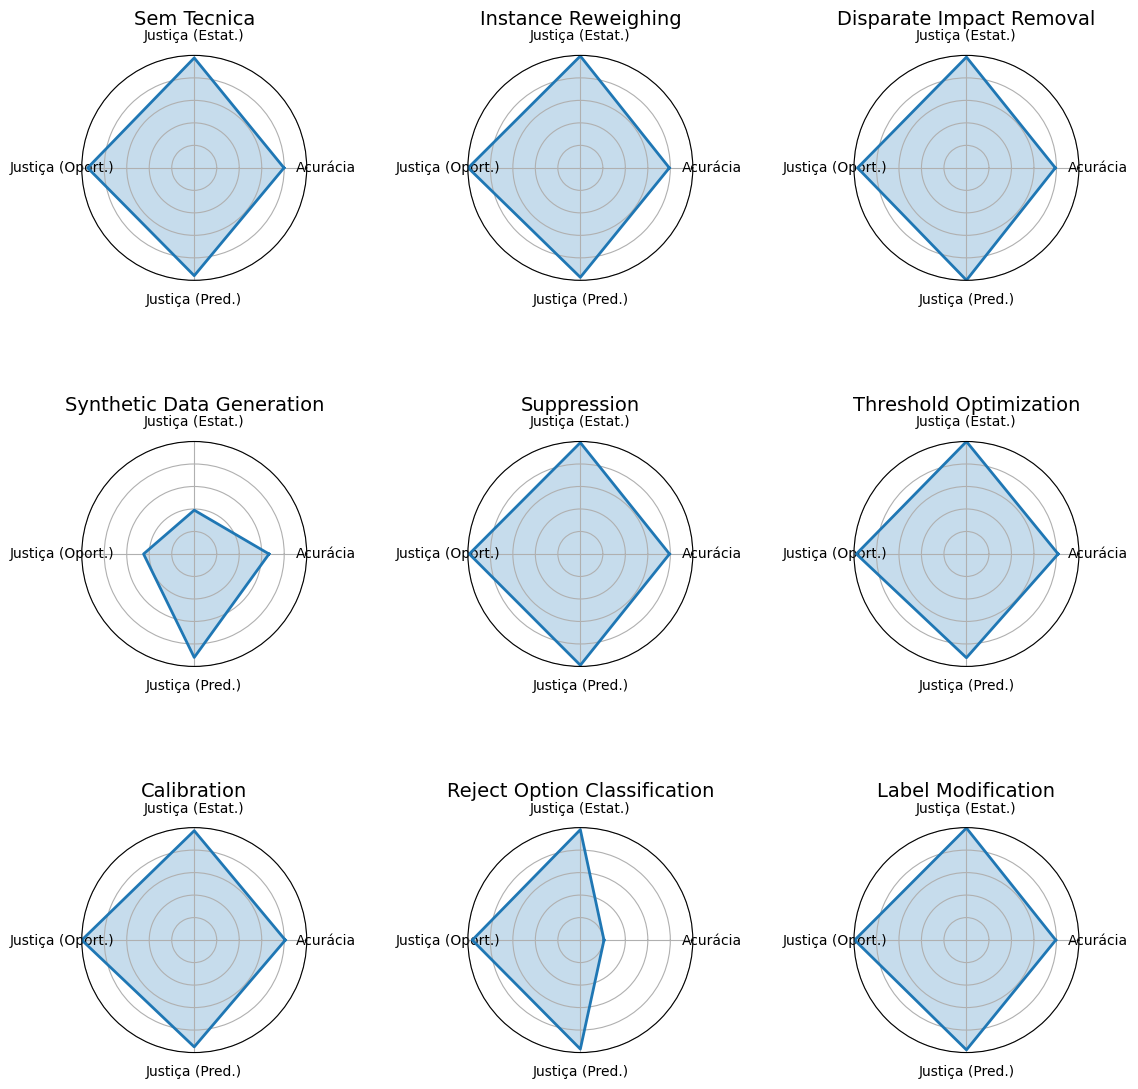

In [94]:
grafico_radar(resultado_global['dataset_1_original']['perceptron'])

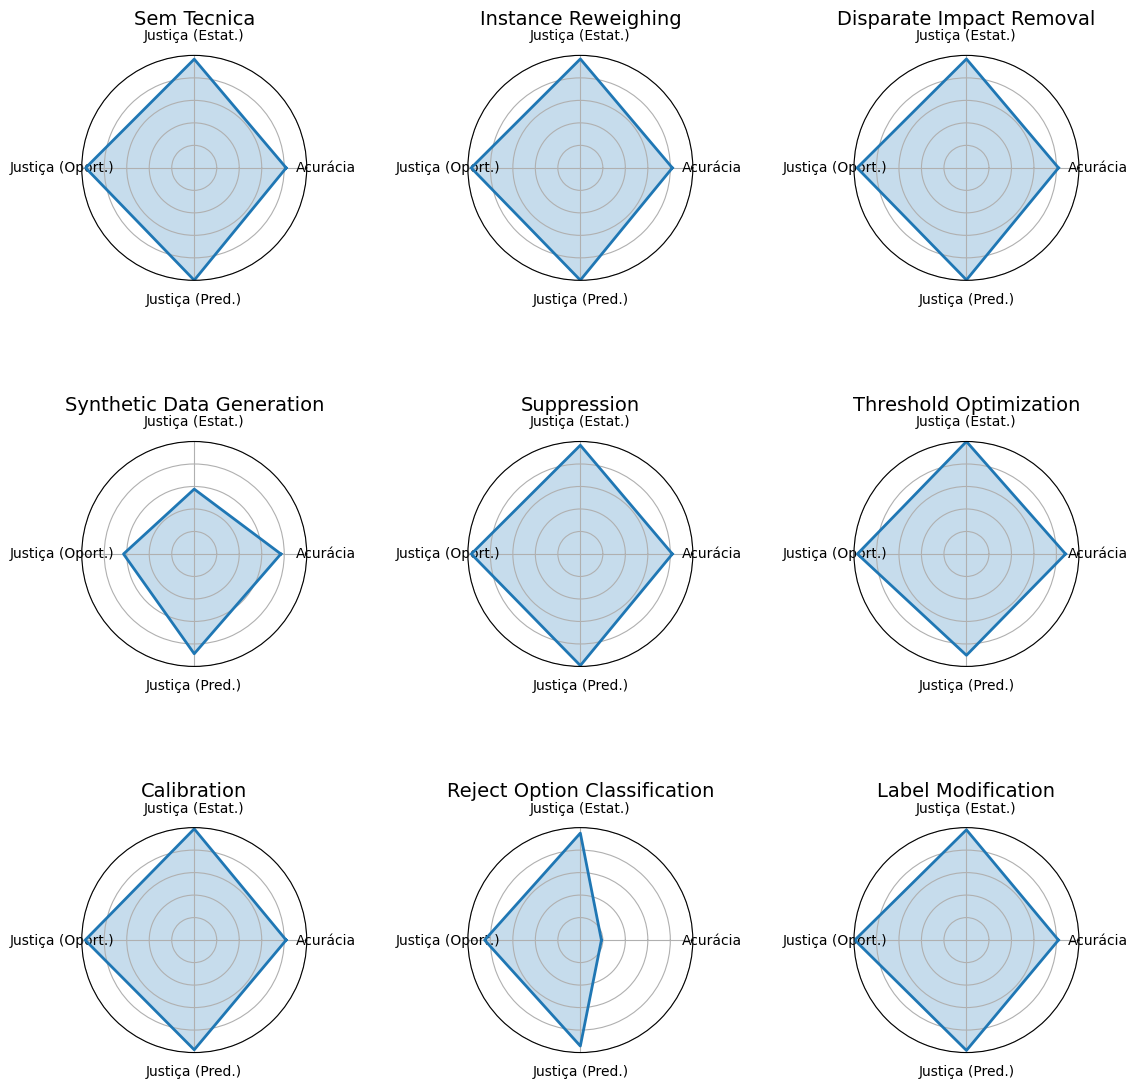

In [95]:
grafico_radar(resultado_global['dataset_1_original']["random_forest"])

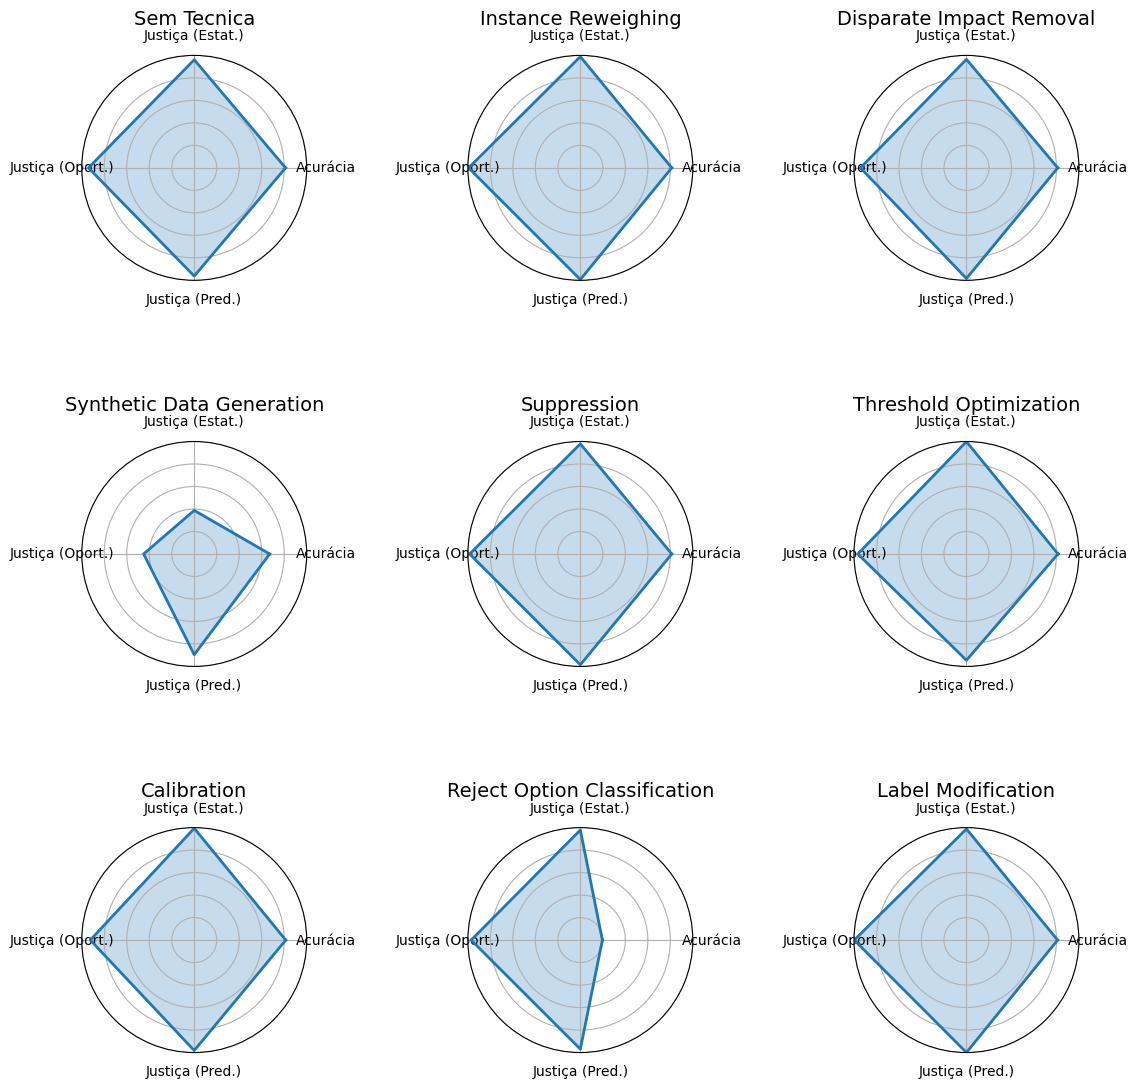

In [96]:
grafico_radar(resultado_global['dataset_1_original']["regressão_logística"])

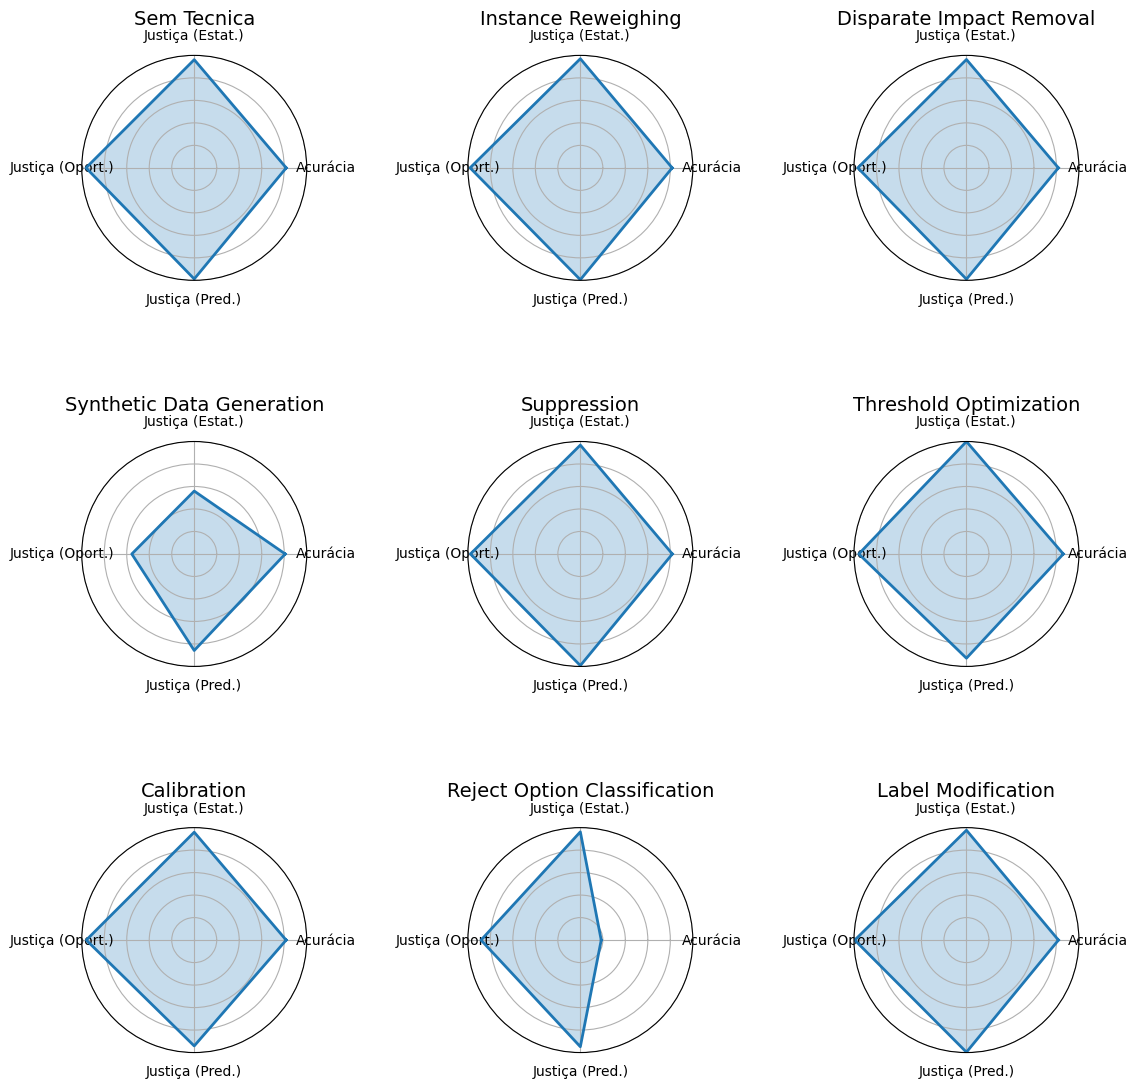

In [97]:
grafico_radar(resultado_global['dataset_1_original']["xgboost"])

# Análise da ordem do gráfico de radar

In [98]:
from itertools import permutations
import math

def encontrar_todas_permutacoes(vetor):
  print(f"Permutações para o vetor: {vetor}\n")
  print("Utiliza-se os angulos em radianos")
  perms = permutations(vetor, len(vetor))

  # Calcula a área para cada permutação
  resultados = []
  for perm in perms:
    print(perm)
    soma = 0
    for x in range(len(vetor)):
      soma += perm[x-1]*perm[x]/2*math.sin((2 * math.pi) /len(vetor))
      print(f"({perm[x]} * {perm[x-1]} / 2) * sen({(2 * math.pi) /len(vetor):.3f}) = {perm[x-1]*perm[x]/2*math.sin((2 * math.pi) /len(vetor)):.3f}")
    print(f"A soma das áreas é {soma:.3f}\n")
    resultados.append(soma)

  resultados.sort()
  for x in resultados:
    print(f"{x:.4f}", end=", ")

In [99]:
encontrar_todas_permutacoes([0.9, 0.8, 0.5, 0.6])

Permutações para o vetor: [0.9, 0.8, 0.5, 0.6]

Utiliza-se os angulos em radianos
(0.9, 0.8, 0.5, 0.6)
(0.9 * 0.6 / 2) * sen(1.571) = 0.270
(0.8 * 0.9 / 2) * sen(1.571) = 0.360
(0.5 * 0.8 / 2) * sen(1.571) = 0.200
(0.6 * 0.5 / 2) * sen(1.571) = 0.150
A soma das áreas é 0.980

(0.9, 0.8, 0.6, 0.5)
(0.9 * 0.5 / 2) * sen(1.571) = 0.225
(0.8 * 0.9 / 2) * sen(1.571) = 0.360
(0.6 * 0.8 / 2) * sen(1.571) = 0.240
(0.5 * 0.6 / 2) * sen(1.571) = 0.150
A soma das áreas é 0.975

(0.9, 0.5, 0.8, 0.6)
(0.9 * 0.6 / 2) * sen(1.571) = 0.270
(0.5 * 0.9 / 2) * sen(1.571) = 0.225
(0.8 * 0.5 / 2) * sen(1.571) = 0.200
(0.6 * 0.8 / 2) * sen(1.571) = 0.240
A soma das áreas é 0.935

(0.9, 0.5, 0.6, 0.8)
(0.9 * 0.8 / 2) * sen(1.571) = 0.360
(0.5 * 0.9 / 2) * sen(1.571) = 0.225
(0.6 * 0.5 / 2) * sen(1.571) = 0.150
(0.8 * 0.6 / 2) * sen(1.571) = 0.240
A soma das áreas é 0.975

(0.9, 0.6, 0.8, 0.5)
(0.9 * 0.5 / 2) * sen(1.571) = 0.225
(0.6 * 0.9 / 2) * sen(1.571) = 0.270
(0.8 * 0.6 / 2) * sen(1.571) = 0.240
(0.5 *

In [100]:
encontrar_todas_permutacoes([0.9, 0.9, 0.5, 0.3, 0.3])

Permutações para o vetor: [0.9, 0.9, 0.5, 0.3, 0.3]

Utiliza-se os angulos em radianos
(0.9, 0.9, 0.5, 0.3, 0.3)
(0.9 * 0.3 / 2) * sen(1.257) = 0.128
(0.9 * 0.9 / 2) * sen(1.257) = 0.385
(0.5 * 0.9 / 2) * sen(1.257) = 0.214
(0.3 * 0.5 / 2) * sen(1.257) = 0.071
(0.3 * 0.3 / 2) * sen(1.257) = 0.043
A soma das áreas é 0.842

(0.9, 0.9, 0.5, 0.3, 0.3)
(0.9 * 0.3 / 2) * sen(1.257) = 0.128
(0.9 * 0.9 / 2) * sen(1.257) = 0.385
(0.5 * 0.9 / 2) * sen(1.257) = 0.214
(0.3 * 0.5 / 2) * sen(1.257) = 0.071
(0.3 * 0.3 / 2) * sen(1.257) = 0.043
A soma das áreas é 0.842

(0.9, 0.9, 0.3, 0.5, 0.3)
(0.9 * 0.3 / 2) * sen(1.257) = 0.128
(0.9 * 0.9 / 2) * sen(1.257) = 0.385
(0.3 * 0.9 / 2) * sen(1.257) = 0.128
(0.5 * 0.3 / 2) * sen(1.257) = 0.071
(0.3 * 0.5 / 2) * sen(1.257) = 0.071
A soma das áreas é 0.785

(0.9, 0.9, 0.3, 0.3, 0.5)
(0.9 * 0.5 / 2) * sen(1.257) = 0.214
(0.9 * 0.9 / 2) * sen(1.257) = 0.385
(0.3 * 0.9 / 2) * sen(1.257) = 0.128
(0.3 * 0.3 / 2) * sen(1.257) = 0.043
(0.5 * 0.3 / 2) * sen(1.257)

In [101]:
encontrar_todas_permutacoes([0.8, 0.7, 0.9, 1, 0.6])

Permutações para o vetor: [0.8, 0.7, 0.9, 1, 0.6]

Utiliza-se os angulos em radianos
(0.8, 0.7, 0.9, 1, 0.6)
(0.8 * 0.6 / 2) * sen(1.257) = 0.228
(0.7 * 0.8 / 2) * sen(1.257) = 0.266
(0.9 * 0.7 / 2) * sen(1.257) = 0.300
(1 * 0.9 / 2) * sen(1.257) = 0.428
(0.6 * 1 / 2) * sen(1.257) = 0.285
A soma das áreas é 1.507

(0.8, 0.7, 0.9, 0.6, 1)
(0.8 * 1 / 2) * sen(1.257) = 0.380
(0.7 * 0.8 / 2) * sen(1.257) = 0.266
(0.9 * 0.7 / 2) * sen(1.257) = 0.300
(0.6 * 0.9 / 2) * sen(1.257) = 0.257
(1 * 0.6 / 2) * sen(1.257) = 0.285
A soma das áreas é 1.488

(0.8, 0.7, 1, 0.9, 0.6)
(0.8 * 0.6 / 2) * sen(1.257) = 0.228
(0.7 * 0.8 / 2) * sen(1.257) = 0.266
(1 * 0.7 / 2) * sen(1.257) = 0.333
(0.9 * 1 / 2) * sen(1.257) = 0.428
(0.6 * 0.9 / 2) * sen(1.257) = 0.257
A soma das áreas é 1.512

(0.8, 0.7, 1, 0.6, 0.9)
(0.8 * 0.9 / 2) * sen(1.257) = 0.342
(0.7 * 0.8 / 2) * sen(1.257) = 0.266
(1 * 0.7 / 2) * sen(1.257) = 0.333
(0.6 * 1 / 2) * sen(1.257) = 0.285
(0.9 * 0.6 / 2) * sen(1.257) = 0.257
A soma das áreas 